# 從求助到資源缺口：PTT Disabled 板五年身心障礙資訊需求、政府統計對照與互助網絡分析

## 研究動機

身心障礙者在日常生活中面臨的問題，常跨越制度、醫療、就學、就業、交通、輔具與生活適應等不同領域。雖然政府、學校與民間組織提供許多正式資源，但實際使用時仍可能遇到資訊分散、申請流程不清楚、個人情境難以對應制度規範等問題。因此，使用者會轉向 PTT Disabled 板這類非正式社群，尋求經驗分享、資源線索與情緒支持。

本研究將 PTT Disabled 板視為一個公開的社群討論樣本，分析近五年板友在社群中提出的需求類型、回應狀況與互助網絡，並加入衛福部身心障礙公開統計作為宏觀背景。研究重點不是代表所有身心障礙者，而是觀察「正式服務之外，使用者還會把哪些問題帶到社群中求助」，以及這些社群需求如何對照政府統計與服務資源。

## 研究問題

- RQ1：近五年 Disabled 板最常出現哪些需求類型？
- RQ2：哪些主題屬於「發文多但回應少」，可能代表資訊或服務缺口？
- RQ3：不同需求類型的情緒與語氣有何差異？
- RQ4：社群互助是否集中在少數關鍵回覆者，或由多數使用者分散支持？
- RQ5：PTT 社群中的需求缺口，如何對照衛福部身心障礙人口、生活補助與輔具補助公開統計？
- RQ6：高缺口主題背後的具體卡點是資格流程、資訊入口、經驗推薦、歧視壓力，還是環境限制？

## 分析範圍與倫理說明

- 資料來源為 PTT Disabled 板公開文章。
- 時間範圍設定為 2021-06-19 至 2026-06-19。
- 政府統計只作為宏觀背景與制度對照，不直接推論 PTT 發文者的個人狀況。
- 作者與推文者會匿名化為節點代號，避免在敏感主題下直接暴露 ID。
- 本報告只分析公開文字與互動結構，不推論個人疾病、障礙類別或真實身分。

In [1]:
import ast
import json
import math
import re
import time
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from urllib.parse import urljoin
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import jieba
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from IPython.display import Markdown, display
from matplotlib import font_manager
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

try:
    from snownlp import SnowNLP
    SNOWNLP_AVAILABLE = True
except Exception:
    SNOWNLP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = Path.cwd()
REPO_DIR = PROJECT_DIR.parents[1]
BOARD = "Disabled"
BASE_URL = "https://www.ptt.cc"
BOARD_URL = f"{BASE_URL}/bbs/{BOARD}/index.html"
REFERENCE_DATE = pd.Timestamp("2026-06-19")
START_DATE = REFERENCE_DATE - pd.DateOffset(years=5)
START_TS = int(START_DATE.timestamp())

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"
DATA_GOV_DIR = PROJECT_DIR / "data" / "gov"
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIG_DIR = PROJECT_DIR / "outputs" / "figures"
TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
NETWORK_DIR = PROJECT_DIR / "outputs" / "network"

for folder in [DATA_RAW_DIR, DATA_GOV_DIR, DATA_PROCESSED_DIR, FIG_DIR, TABLE_DIR, NETWORK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RAW_CSV = DATA_RAW_DIR / "ptt_disabled_articles_raw_5y.csv"
CLEAN_CSV = DATA_PROCESSED_DIR / "ptt_disabled_articles_clean_5y.csv"
ERROR_LOG = DATA_RAW_DIR / "ptt_disabled_scrape_errors_5y.csv"

GOV_SOURCES = {
    "population_by_category_city": {
        "title": "2.3.1 身心障礙者人數按類別及縣市別分",
        "url": "https://www.mohw.gov.tw/dl-69411-96eddda2-305c-4c30-acc7-b9a706d7a22f.html",
        "filename": "2_3_1_disability_population_by_category_city.ods",
    },
    "living_allowance": {
        "title": "2.3.10 身心障礙者生活補助",
        "url": "https://www.mohw.gov.tw/dl-69248-fa9f6837-13de-4a6d-985b-7ef4e654bff2.html",
        "filename": "2_3_10_living_allowance.xlsx",
    },
    "assistive_device_subsidy": {
        "title": "2.3.11 身心障礙者生活輔具補助",
        "url": "https://www.mohw.gov.tw/dl-69250-7099a424-9de8-4307-bd34-cdbbbc325e0d.html",
        "filename": "2_3_11_assistive_device_subsidy.xlsx",
    },
}

print(f"Project dir: {PROJECT_DIR}")
print(f"Reference date: {REFERENCE_DATE.date()}")
print(f"Analysis window: {START_DATE.date()} to {REFERENCE_DATE.date()}")
print(f"SnowNLP available: {SNOWNLP_AVAILABLE}")

/Users/ye/Desktop/碩士/6-二下/社群媒體分析/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Project dir: /Users/ye/Desktop/碩士/6-二下/社群媒體分析/8-期末專案/ptt_disabled_project
Reference date: 2026-06-19
Analysis window: 2021-06-19 to 2026-06-19
SnowNLP available: True


## 0. 視覺化與字典設定

這段設定中文字型、課程提供的結巴辭典，以及本研究的身心障礙領域詞彙。自訂詞的目的，是避免「身心障礙」、「身障手冊」、「無障礙」、「助聽器」等關鍵詞在斷詞時被切得太碎。

In [2]:
plt.rcParams["axes.unicode_minus"] = False

font_candidates = [
    REPO_DIR / "SMA_2026S-main" / "week14" / "TaipeiSansTCBeta-Regular.ttf",
    REPO_DIR / "SMA_2026S-main" / "week12" / "TaipeiSansTCBeta-Regular.ttf",
    Path("/System/Library/Fonts/PingFang.ttc"),
    Path("/System/Library/Fonts/STHeiti Light.ttc"),
]
FONT_PATH = next((p for p in font_candidates if p.exists()), None)
if FONT_PATH:
    font_manager.fontManager.addfont(str(FONT_PATH))
    font_name = font_manager.FontProperties(fname=str(FONT_PATH)).get_name()
    plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
    print(f"使用中文字型：{FONT_PATH}")
else:
    print("提醒：未找到中文字型，圖表中文字可能顯示不完整。")

jieba_dict = REPO_DIR / "SMA_2026S-main" / "week09" / "dict" / "dict.txt.big"
if jieba_dict.exists():
    jieba.set_dictionary(str(jieba_dict))
    print(f"使用課程結巴字典：{jieba_dict}")

domain_words = [
    "身心障礙", "身障", "身障者", "身障手冊", "身心障礙手冊", "障礙者",
    "無障礙", "輔具", "助聽器", "輪椅", "電動輪椅", "爬梯機", "照顧者",
    "國考", "高考", "特考", "延長考試時間", "電腦作答", "就業服務",
    "職缺", "補助", "社福", "長照", "復康巴士", "愛心票", "陪同票",
    "視覺障礙", "聽覺障礙", "肌肉萎縮", "手語", "職務再設計",
]
for word in domain_words:
    jieba.add_word(word)

stopword_paths = [
    REPO_DIR / "SMA_2026S-main" / "week09" / "dict" / "stop_words.txt",
    REPO_DIR / "SMA_2026S-main" / "week06" / "dict" / "stopwords.txt",
    REPO_DIR / "SMA_2026S-main" / "week03" / "dict" / "stopwords.txt",
]
stopwords = set()
for path in stopword_paths:
    if path.exists():
        stopwords.update(path.read_text(encoding="utf-8", errors="ignore").splitlines())

stopwords.update(
    [
        "請問", "有人", "想問", "知道", "大家", "自己", "一個", "可以", "沒有",
        "不是", "因為", "所以", "如果", "這個", "那個", "還是", "就是", "覺得",
        "真的", "目前", "謝謝", "文章", "問題", "資訊", "閒聊", "其他", "新聞",
        "公告", "徵求", "請益", "轉錄", "發信站", "批踢踢", "實業坊", "ptt",
    ]
)
print(f"停用字數量：{len(stopwords):,}")

Building prefix dict from /Users/ye/Desktop/碩士/6-二下/社群媒體分析/SMA_2026S-main/week09/dict/dict.txt.big ...


Loading model from cache /var/folders/0x/f7rgr96j42bfb8yq04lhwm9r0000gn/T/jieba.u37d6e13d332893496971806ea7b04b6a.cache


使用中文字型：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/SMA_2026S-main/week14/TaipeiSansTCBeta-Regular.ttf
使用課程結巴字典：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/SMA_2026S-main/week09/dict/dict.txt.big


Loading model cost 0.380 seconds.


Prefix dict has been built successfully.


停用字數量：1,770


## 1. 抓取與整理 PTT Disabled 板資料

若 `data/raw/ptt_disabled_articles_raw_5y.csv` 已存在，Notebook 會直接讀取 5 年版快取，避免每次重跑都重新抓取 PTT。若尚未存在，則從看板最新頁一路往前翻，依文章 URL 中的時間戳與文章頁實際日期篩選近五年文章。

In [3]:
session = requests.Session()
session.headers.update(
    {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome Safari",
    }
)
session.cookies.set("over18", "1")

def fetch_html(url, timeout=20):
    response = session.get(url, timeout=timeout)
    response.raise_for_status()
    response.encoding = "utf-8"
    return response.text

def article_timestamp_from_href(href):
    match = re.search(r"/M\.(\d+)\.", href or "")
    if match:
        return int(match.group(1))
    return None

def parse_list_page(html):
    soup = BeautifulSoup(html, "html.parser")
    prev_url = None
    for a in soup.select(".btn-group-paging a"):
        if "上頁" in a.get_text(strip=True):
            prev_url = urljoin(BASE_URL, a.get("href"))
            break

    links = []
    for ent in soup.select(".r-ent"):
        title_node = ent.select_one(".title a")
        if not title_node:
            continue
        href = title_node.get("href")
        title = title_node.get_text(strip=True)
        author_node = ent.select_one(".author")
        date_node = ent.select_one(".date")
        nrec_node = ent.select_one(".nrec")
        mark_node = ent.select_one(".mark")
        links.append(
            {
                "href": urljoin(BASE_URL, href),
                "title_list": title,
                "author_list": author_node.get_text(strip=True) if author_node else "",
                "date_list": date_node.get_text(strip=True) if date_node else "",
                "nrec_list": nrec_node.get_text(strip=True) if nrec_node else "",
                "mark": mark_node.get_text(strip=True) if mark_node else "",
                "url_ts": article_timestamp_from_href(href),
            }
        )
    return prev_url, links

def parse_article_page(html, url):
    soup = BeautifulSoup(html, "html.parser")
    main = soup.select_one("#main-content")
    if main is None:
        raise ValueError("missing #main-content")

    meta_values = [node.get_text(strip=True) for node in main.select(".article-meta-value")]
    author = meta_values[0] if len(meta_values) >= 1 else ""
    board = meta_values[1] if len(meta_values) >= 2 else BOARD
    title = meta_values[2] if len(meta_values) >= 3 else ""
    article_time_text = meta_values[3] if len(meta_values) >= 4 else ""
    article_dt = pd.to_datetime(article_time_text, errors="coerce")

    comments = []
    for push in main.select("div.push"):
        tag = push.select_one(".push-tag")
        user = push.select_one(".push-userid")
        content = push.select_one(".push-content")
        dt = push.select_one(".push-ipdatetime")
        content_text = content.get_text(" ", strip=True).lstrip(":").strip() if content else ""
        comments.append(
            {
                "tag": tag.get_text(strip=True) if tag else "",
                "user": user.get_text(strip=True) if user else "",
                "content": content_text,
                "datetime_text": dt.get_text(strip=True) if dt else "",
            }
        )

    for node in main.select(".article-metaline, .article-metaline-right, div.push, #article-polling"):
        node.decompose()
    content_text = main.get_text("\n", strip=True)
    content_text = re.split(r"※\s*發信站", content_text)[0]
    content_text = re.sub(r"--\s*$", "", content_text).strip()

    return {
        "article_id": Path(url).name.replace(".html", ""),
        "artUrl": url,
        "board": board,
        "author_raw": author,
        "artTitle": title,
        "artDate": article_dt,
        "artTimeText": article_time_text,
        "artContent": content_text,
        "push_count": len(comments),
        "comments_json": json.dumps(comments, ensure_ascii=False),
    }

def scrape_disabled_board(max_list_pages=260, sleep_seconds=0.12):
    rows = []
    errors = []
    seen_urls = set()
    list_url = BOARD_URL

    for page_no in range(1, max_list_pages + 1):
        print(f"[list {page_no:03d}] {list_url}")
        try:
            html = fetch_html(list_url)
            prev_url, links = parse_list_page(html)
        except Exception as error:
            errors.append({"stage": "list", "url": list_url, "error": repr(error)})
            break

        ts_values = [item["url_ts"] for item in links if item.get("url_ts")]
        recent_links = [
            item for item in links
            if item.get("url_ts") and item["url_ts"] >= START_TS and item["href"] not in seen_urls
        ]

        for item in recent_links:
            seen_urls.add(item["href"])
            try:
                row = parse_article_page(fetch_html(item["href"]), item["href"])
                row.update({k: item[k] for k in ["title_list", "author_list", "date_list", "nrec_list", "mark"]})
                rows.append(row)
            except Exception as error:
                errors.append({"stage": "article", "url": item["href"], "error": repr(error)})
            time.sleep(sleep_seconds)

        if ts_values and max(ts_values) < START_TS and rows:
            print("已到達分析起始日前的頁面，停止往前翻頁。")
            break
        if not prev_url or prev_url == list_url:
            break
        list_url = prev_url
        time.sleep(sleep_seconds)

    raw_df = pd.DataFrame(rows)
    error_df = pd.DataFrame(errors)
    return raw_df, error_df

if RAW_CSV.exists() and RAW_CSV.stat().st_size > 0:
    raw_df = pd.read_csv(RAW_CSV, parse_dates=["artDate"])
    try:
        error_df = pd.read_csv(ERROR_LOG) if ERROR_LOG.exists() else pd.DataFrame()
    except Exception:
        error_df = pd.DataFrame()
    print(f"讀取既有 raw CSV：{RAW_CSV}")
else:
    raw_df, error_df = scrape_disabled_board()
    raw_df.to_csv(RAW_CSV, index=False, encoding="utf-8-sig")
    error_df.to_csv(ERROR_LOG, index=False, encoding="utf-8-sig")
    print(f"已寫入 raw CSV：{RAW_CSV}")

print(f"raw articles: {len(raw_df):,}")
print(f"scrape errors: {len(error_df):,}")
display(raw_df.head(3))

讀取既有 raw CSV：/Users/ye/Desktop/碩士/6-二下/社群媒體分析/8-期末專案/ptt_disabled_project/data/raw/ptt_disabled_articles_raw_5y.csv
raw articles: 417
scrape errors: 0


,article_id,artUrl,board,author_raw,artTitle,artDate,artTimeText,artContent,push_count,comments_json,title_list,author_list,date_list,nrec_list,mark
0,M.1771825584.A.9C2,https://www.ptt.cc/bbs/Disabled/M.1771825584.A.9C2.html,Disabled,may46 (蕾夢派),[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊）,2026-02-23 13:46:22,Mon Feb 23 13:46:22 2026,一、報名日期：即日起至115年3月2日 (一) 中午12:00止。\n\n二、甄選面試日期：115年3月5日 (三) 上午10時於本校校史室(請於9時50分報到)。\n\n三、聘期：本職缺自實際報到日起至 115 年 12 月 31...,0,[],[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊）,may46,2/23,NaN,NaN
1,M.1772271409.A.BD9,https://www.ptt.cc/bbs/Disabled/M.1772271409.A.BD9.html,Disabled,boldt (沒人注意),[問題] 請問國考的申請改用電腦作答的部分,2026-02-28 17:36:47,Sat Feb 28 17:36:47 2026,小弟肌肉萎縮~\n\n今年想報考高考資訊處理\n\n想說可以申請改用電腦作答，\n\n但問題就是…\n\n資訊處理的考科中，很多是最好使用畫圖說明的\n\n我覺得改用電腦作答應該沒辦法好好將圖畫出來\n\n又想說乾脆申請手寫應試，反...,11,"[{""tag"": ""推"", ""user"": ""ting69"", ""content"": ""電腦作答 是開一個word檔讓你的作答 選擇題會畫好格子讓你"", ""datetime_text"": ""03/04 12:03""}, {""tag""...",[問題] 請問國考的申請改用電腦作答的部分,boldt,2/28,4.0,NaN
2,M.1773758512.A.50A,https://www.ptt.cc/bbs/Disabled/M.1773758512.A.50A.html,Disabled,Gina901026 (UUfobJqgLPTuJcJetMSFnSF),[學術],2026-03-17 22:41:50,Tue Mar 17 22:41:50 2026,大家好\n我是中山醫學大學醫學社會暨社會工作學系的碩士研究生張琬婷，目前正在進行一項關於\n中途視覺障礙者自我決策與自立生活經驗的碩士論文研究（本研究已通過人體研究倫理審\n查）。\n這項研究想邀請你分享：\n1.在成為中途視覺障礙...,0,[],[資訊] 徵求中途視覺障礙受訪者,Gina901026,3/17,NaN,NaN


## 2. 資料篩選、匿名化與基本描述

這段會做三件事：

1. 將日期限制在近五年。
2. 移除公告文，避免板務公告干擾需求分析。
3. 將作者與推文者匿名化，後續網絡分析只呈現節點代號。

In [4]:
def extract_title_tag(title):
    match = re.search(r"\[([^\]]+)\]", str(title))
    if match:
        return match.group(1).strip()
    return "無標籤"

def normalize_author(author_text):
    text = str(author_text or "").strip()
    return re.sub(r"\s*\(.*?\)\s*$", "", text).strip() or "unknown"

def load_comments(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

df = raw_df.copy()
df["artDate"] = pd.to_datetime(df["artDate"], errors="coerce")
df["title_tag"] = df["artTitle"].apply(extract_title_tag)
df["author_id"] = df["author_raw"].apply(normalize_author)
df["comments"] = df["comments_json"].apply(load_comments)
df["comment_user_count"] = df["comments"].apply(lambda xs: len({x.get("user", "") for x in xs if x.get("user")}))
df["year_month"] = df["artDate"].dt.strftime("%Y-%m")

in_window = df["artDate"].between(START_DATE, REFERENCE_DATE + pd.Timedelta(days=1), inclusive="both")
non_announcement = ~df["title_tag"].isin(["公告"])
df = df.loc[in_window & non_announcement].drop_duplicates("artUrl").reset_index(drop=True)

all_users = sorted(
    set(df["author_id"].dropna())
    | {c.get("user", "") for comments in df["comments"] for c in comments if c.get("user")}
)
user_map = {user: f"U{idx:04d}" for idx, user in enumerate(all_users, 1)}
df["author_anon"] = df["author_id"].map(user_map).fillna("U0000")

def anonymize_comments(comments):
    anon_comments = []
    for comment in comments:
        item = dict(comment)
        item["user_anon"] = user_map.get(item.get("user", ""), "U0000")
        item.pop("user", None)
        anon_comments.append(item)
    return anon_comments

df["comments_anon"] = df["comments"].apply(anonymize_comments)
df["comments_anon_json"] = df["comments_anon"].apply(lambda xs: json.dumps(xs, ensure_ascii=False))

summary = pd.DataFrame(
    {
        "metric": [
            "analysis_start",
            "analysis_end",
            "article_count",
            "unique_authors",
            "total_pushes",
            "unique_commenters",
        ],
        "value": [
            str(START_DATE.date()),
            str(REFERENCE_DATE.date()),
            len(df),
            df["author_anon"].nunique(),
            int(df["push_count"].sum()),
            len({c.get("user_anon") for comments in df["comments_anon"] for c in comments if c.get("user_anon")}),
        ],
    }
)
display(summary)
summary.to_csv(TABLE_DIR / "data_summary.csv", index=False, encoding="utf-8-sig")
display(df[["artDate", "artTitle", "title_tag", "push_count", "comment_user_count"]].head(10))

,metric,value
0,analysis_start,2021-06-19
1,analysis_end,2026-06-19
2,article_count,386
3,unique_authors,237
4,total_pushes,3793
5,unique_commenters,567


,artDate,artTitle,title_tag,push_count,comment_user_count
0,2026-02-23 13:46:22,[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊）,資訊,0,0
1,2026-02-28 17:36:47,[問題] 請問國考的申請改用電腦作答的部分,問題,11,3
2,2026-03-17 22:41:50,[學術],學術,0,0
3,2026-05-02 20:44:58,[閒聊] 助聽器請益,閒聊,4,1
4,2026-05-05 23:00:14,Fw: [新聞] 全障運5/23開幕 新北：歡迎民眾線上索票,新聞,1,1
5,2026-05-14 19:18:09,Fw: [新聞] 聾人文化先驅顧玉山 獲文化部台灣手語貢獻獎,新聞,0,0
6,2026-05-21 19:26:30,[心情] 身障者提供給我的高品質服務（勝利基金會,心情,4,3
7,2026-05-26 20:10:23,[資訊] 0527-弱勢行人對車告警系統成果說明會,資訊,0,0
8,2025-10-20 13:50:05,[資訊] 中信兄弟樂天桃猿第3場愛心票券出售,資訊,0,0
9,2025-10-28 12:45:37,[問題] 請問這台電動爬梯輪椅多少錢呢？,問題,2,2


## 3. 文字清理與斷詞

分析文本採用「標題 + 內文」。標題能提供文章目的，內文則提供需求脈絡。這段會移除網址、簽名檔與多餘符號，再用結巴斷詞建立後續詞頻、TF-IDF、主題模型所需的 token 欄位。

In [5]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"imgur\S*", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Sent from .*", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"[^0-9A-Za-z\u4e00-\u9fff\s\[\]（）()，。！？、；：:,.!?/-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize(text):
    tokens = []
    for token in jieba.lcut(text):
        token = token.strip()
        if not token or token in stopwords:
            continue
        if len(token) <= 1:
            continue
        if re.fullmatch(r"\d+", token):
            continue
        tokens.append(token)
    return tokens

df["analysis_text"] = (df["artTitle"].fillna("") + " " + df["artContent"].fillna("")).apply(clean_text)
df["text_length"] = df["analysis_text"].str.len()
df["tokens"] = df["analysis_text"].apply(tokenize)
df["token_text"] = df["tokens"].apply(" ".join)

token_rows = []
for _, row in df.iterrows():
    for token in row["tokens"]:
        token_rows.append({"article_id": row["article_id"], "token": token, "year_month": row["year_month"]})
token_df = pd.DataFrame(token_rows)

clean_export = df.drop(columns=["comments", "comments_anon"], errors="ignore").copy()
clean_export["tokens_json"] = df["tokens"].apply(lambda xs: json.dumps(xs, ensure_ascii=False))
clean_export.to_csv(CLEAN_CSV, index=False, encoding="utf-8-sig")
token_df.to_csv(TABLE_DIR / "token_df.csv", index=False, encoding="utf-8-sig")

print(f"clean articles: {len(df):,}")
print(f"tokens: {len(token_df):,}")
display(df[["artTitle", "analysis_text", "tokens"]].head(3))

clean articles: 386
tokens: 39,050


,artTitle,analysis_text,tokens
0,[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊）,[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊） 一、報名日期：即日起至115年3月2日 (一) 中午12:00止。 二、甄選面試日期：115年3月5日 (三) 上午10時於本校校史室(請於9時50分報到)。 三、聘期：本職缺自實際...,"[龍國, 誠徵, 警衛, 限持, 身心障礙手冊, 報名, 日期, 即日起, 中午, 甄選, 面試, 日期, 上午, 本校, 校史, 請於, 報到, 聘期, 本職, 缺自, 報到, 日起, 日止, 服務, 期滿, 年終, 考核, 辦理..."
1,[問題] 請問國考的申請改用電腦作答的部分,[問題] 請問國考的申請改用電腦作答的部分 小弟肌肉萎縮 今年想報考高考資訊處理 想說可以申請改用電腦作答， 但問題就是 資訊處理的考科中，很多是最好使用畫圖說明的 我覺得改用電腦作答應該沒辦法好好將圖畫出來 又想說乾脆申請手寫應試...,"[國考, 申請, 改用, 電腦作答, 小弟, 肌肉萎縮, 報考, 高考, 申請, 改用, 電腦作答, 考科中, 畫圖, 改用, 電腦作答, 辦法, 圖畫, 乾脆, 申請, 手寫, 應試, 反正, 用畫, 考科並, 長篇大論, 只求,..."
2,[學術],[學術] 大家好 我是中山醫學大學醫學社會暨社會工作學系的碩士研究生張琬婷，目前正在進行一項關於 中途視覺障礙者自我決策與自立生活經驗的碩士論文研究（本研究已通過人體研究倫理審 查）。 這項研究想邀請你分享： 1.在成為中途視覺障礙...,"[學術, 中山醫學, 大學, 醫學, 社會, 社會工作, 學系, 碩士, 研究生, 張琬婷, 一項, 中途, 視覺障礙, 自我, 決策, 自立, 生活, 經驗, 碩士論文, 研究, 研究, 人體, 研究, 倫理, 這項, 研究, 邀..."


## 4. 基本趨勢、標題類別與高頻詞

先看近五年發文量、標題標籤與高頻詞，作為整體資料輪廓。這裡的重點不是只列出詞頻，而是判斷 Disabled 板的公開討論較常是「資訊公告」、「實務求助」、「生活經驗」還是「資源交換」。

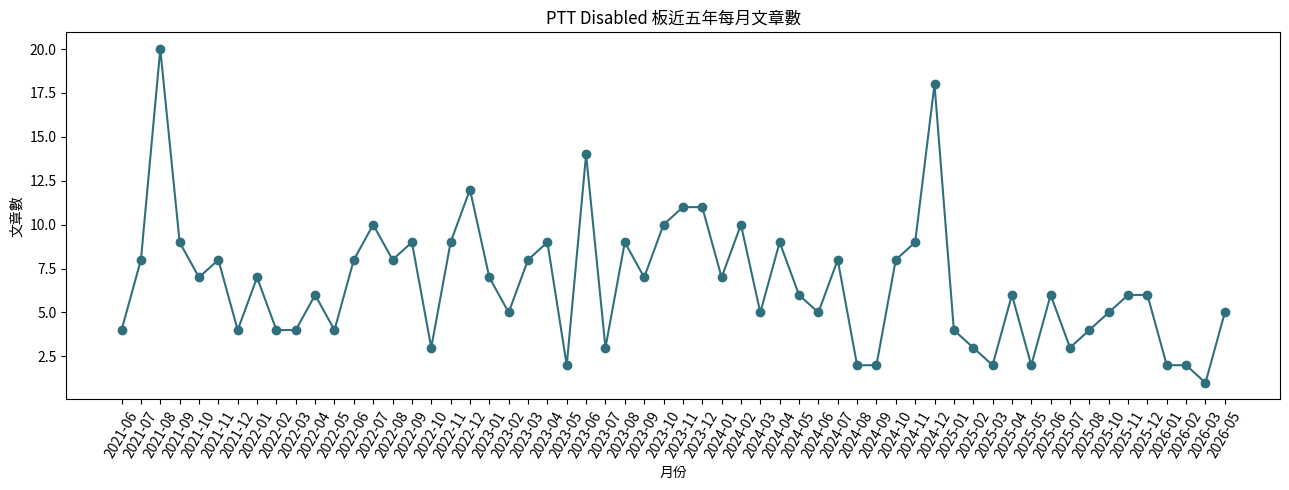

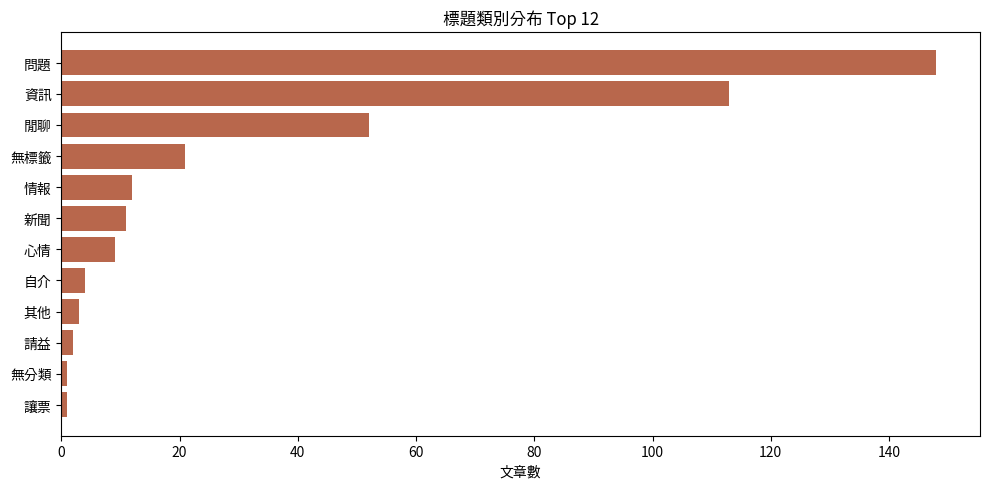

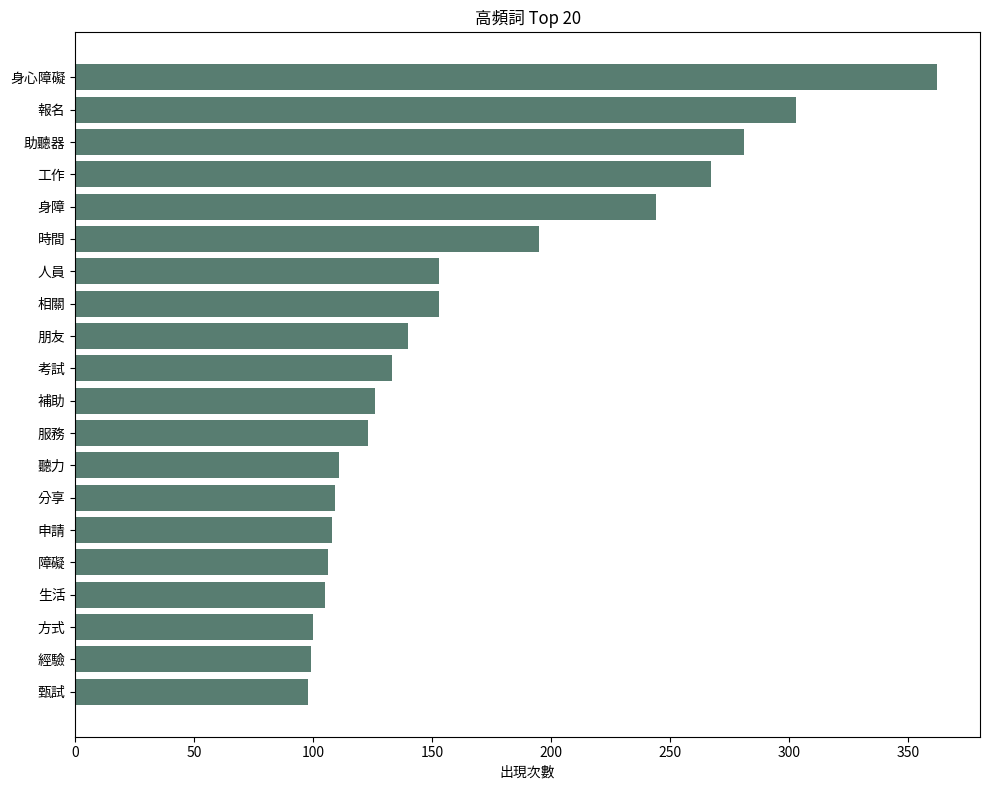

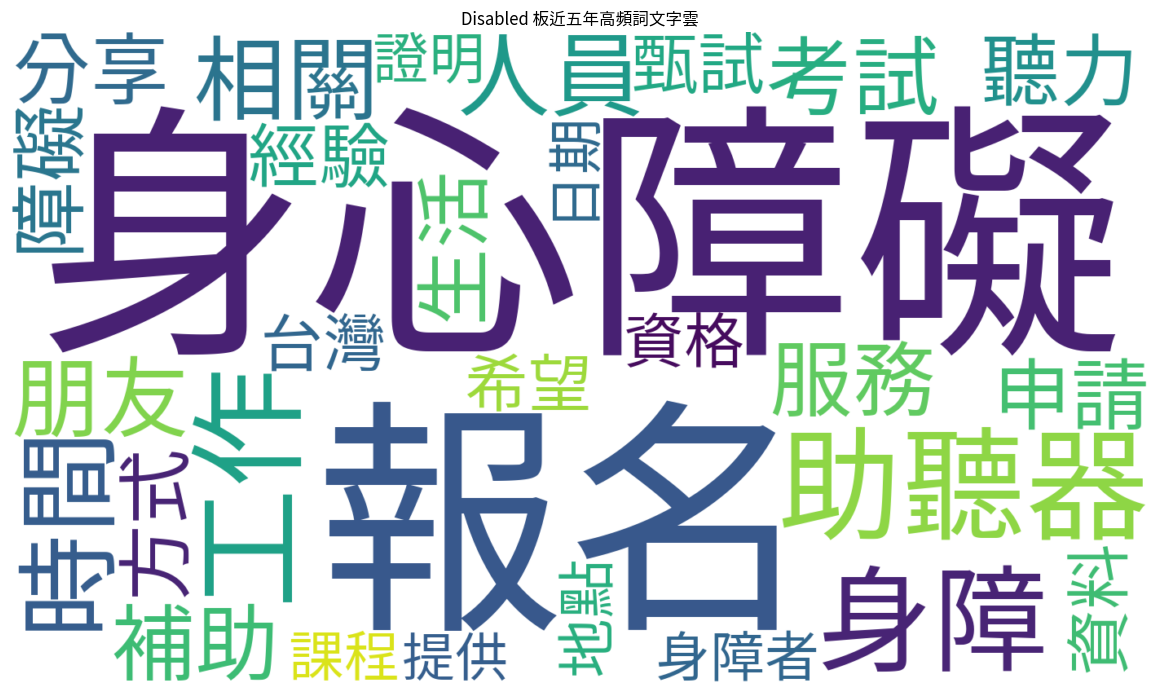

In [6]:
monthly_counts = df.groupby("year_month").size().reset_index(name="article_count").sort_values("year_month")
title_tag_counts = df["title_tag"].value_counts().reset_index()
title_tag_counts.columns = ["title_tag", "article_count"]
top_words = token_df["token"].value_counts().head(30).reset_index()
top_words.columns = ["token", "count"]

monthly_counts.to_csv(TABLE_DIR / "monthly_article_counts.csv", index=False, encoding="utf-8-sig")
title_tag_counts.to_csv(TABLE_DIR / "title_tag_counts.csv", index=False, encoding="utf-8-sig")
top_words.to_csv(TABLE_DIR / "top_words.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(13, 5))
plt.plot(monthly_counts["year_month"], monthly_counts["article_count"], marker="o", color="#2F6F7E")
plt.title("PTT Disabled 板近五年每月文章數")
plt.xlabel("月份")
plt.ylabel("文章數")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_article_counts.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
show_tags = title_tag_counts.head(12).sort_values("article_count")
plt.barh(show_tags["title_tag"], show_tags["article_count"], color="#B8674C")
plt.title("標題類別分布 Top 12")
plt.xlabel("文章數")
plt.tight_layout()
plt.savefig(FIG_DIR / "title_tag_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
show_words = top_words.head(20).sort_values("count")
plt.barh(show_words["token"], show_words["count"], color="#587D71")
plt.title("高頻詞 Top 20")
plt.xlabel("出現次數")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_words.png", dpi=300, bbox_inches="tight")
plt.show()

if len(token_df) > 0:
    freqs = dict(zip(top_words["token"], top_words["count"]))
    wc = WordCloud(
        font_path=str(FONT_PATH) if FONT_PATH else None,
        width=1400,
        height=800,
        background_color="white",
        colormap="viridis",
        max_words=120,
    ).generate_from_frequencies(freqs)
    plt.figure(figsize=(12, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Disabled 板近五年高頻詞文字雲")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "wordcloud.png", dpi=300, bbox_inches="tight")
    plt.show()

## 5. 需求類型字典分類

為了回答「哪些需求最常出現」與「哪些需求可能缺乏回應」，本研究採用可解釋的字典法。每篇文章會依照標題與內文的關鍵詞命中數，標記一個主要需求類型。這比黑箱分類模型更適合期末報告，因為每個分類都能回到關鍵詞與原文脈絡檢查。

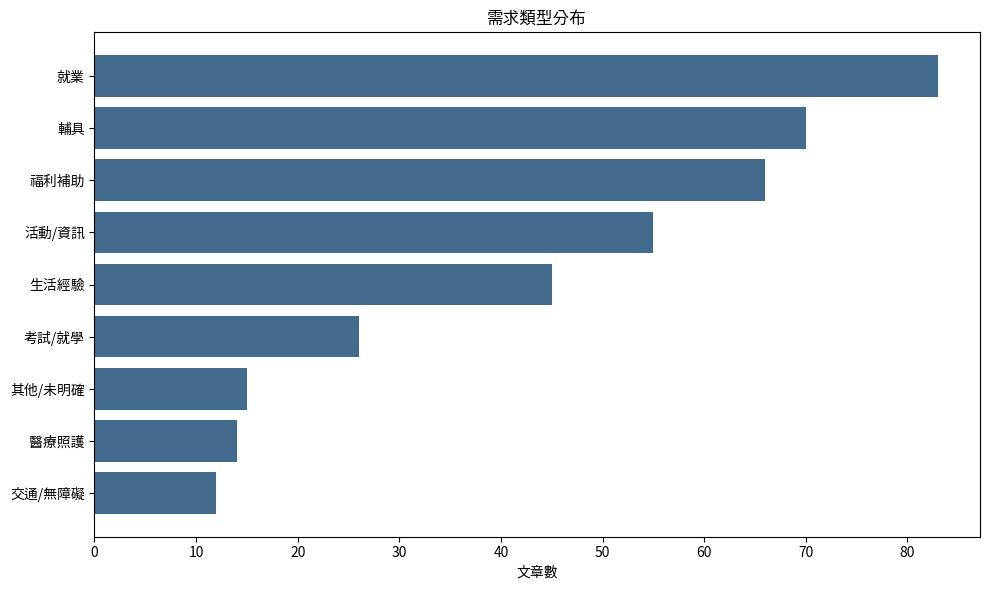

,primary_need,article_count,avg_push_count,median_push_count,zero_reply_ratio,unique_authors
2,就業,83,12.00,3.0,0.325,50
7,輔具,70,13.41,8.0,0.157,63
5,福利補助,66,8.30,5.5,0.197,54
3,活動/資訊,55,3.53,1.0,0.436,41
4,生活經驗,45,11.07,3.0,0.267,37
6,考試/就學,26,11.88,3.0,0.308,18
1,其他/未明確,15,10.07,6.0,0.267,13
8,醫療照護,14,6.57,6.5,0.071,14
0,交通/無障礙,12,5.50,4.0,0.250,10


In [7]:
need_keywords = {
    "考試/就學": ["國考", "高考", "特考", "考試", "電腦作答", "延長考試", "就學", "學校", "學生", "實習", "大學", "研究所"],
    "就業": ["就業", "職缺", "工作", "求職", "面試", "職場", "職務", "招考", "徵才", "警衛", "台電", "公司"],
    "福利補助": ["補助", "津貼", "社福", "福利", "手冊", "證明", "鑑定", "申請", "資格", "政府", "長照", "低收"],
    "輔具": ["輔具", "輪椅", "電動輪椅", "助聽器", "爬梯", "義肢", "拐杖", "居家改善", "復健", "廠商"],
    "交通/無障礙": ["交通", "無障礙", "復康巴士", "捷運", "公車", "車位", "停車", "行人", "坡道", "電梯"],
    "醫療照護": ["醫療", "醫院", "醫師", "診斷", "照護", "看護", "治療", "肌肉萎縮", "視覺障礙", "聽覺障礙", "失能"],
    "生活經驗": ["心得", "心情", "生活", "家人", "照顧", "陪伴", "經驗", "分享", "困難", "麻煩", "不方便"],
    "活動/資訊": ["活動", "講座", "課程", "票", "愛心票", "演唱會", "徵求", "受訪", "研究", "問卷", "新聞"],
}

def classify_need(text):
    scores = {}
    for category, keywords in need_keywords.items():
        scores[category] = sum(str(text).count(keyword) for keyword in keywords)
    best_category, best_score = max(scores.items(), key=lambda x: x[1])
    if best_score <= 0:
        return "其他/未明確", json.dumps(scores, ensure_ascii=False)
    return best_category, json.dumps(scores, ensure_ascii=False)

classified = df["analysis_text"].apply(classify_need)
df["primary_need"] = classified.apply(lambda x: x[0])
df["need_scores_json"] = classified.apply(lambda x: x[1])

need_summary = (
    df.groupby("primary_need")
    .agg(
        article_count=("article_id", "count"),
        avg_push_count=("push_count", "mean"),
        median_push_count=("push_count", "median"),
        zero_reply_ratio=("push_count", lambda s: float((s == 0).mean())),
        unique_authors=("author_anon", "nunique"),
    )
    .reset_index()
)
need_summary["avg_push_count"] = need_summary["avg_push_count"].round(2)
need_summary["zero_reply_ratio"] = need_summary["zero_reply_ratio"].round(3)
need_summary = need_summary.sort_values("article_count", ascending=False)
need_summary.to_csv(TABLE_DIR / "need_category_summary.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 6))
need_plot = need_summary.sort_values("article_count")
plt.barh(need_plot["primary_need"], need_plot["article_count"], color="#426A8C")
plt.title("需求類型分布")
plt.xlabel("文章數")
plt.tight_layout()
plt.savefig(FIG_DIR / "need_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(need_summary)

## 6. 需求缺口：高發文量但低回應主題

本研究將「需求缺口」操作化為：某類需求文章數較多，但平均推文數較少、零回覆比例較高。這不代表該需求一定沒有正式服務，而是代表在這個社群樣本中，使用者常提出相關問題，但社群回應相對不足，值得政策服務者或資訊設計者優先檢視。

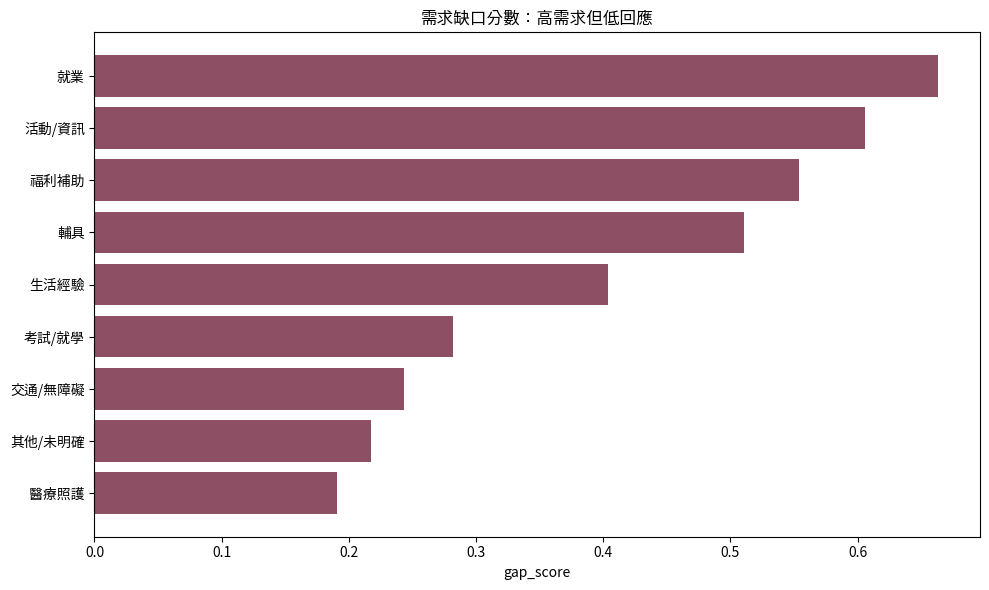

,primary_need,article_count,avg_push_count,zero_reply_ratio,gap_score
2,就業,83,12.00,0.325,0.663
3,活動/資訊,55,3.53,0.436,0.606
5,福利補助,66,8.30,0.197,0.554
7,輔具,70,13.41,0.157,0.511
4,生活經驗,45,11.07,0.267,0.404
6,考試/就學,26,11.88,0.308,0.282
0,交通/無障礙,12,5.50,0.250,0.243
1,其他/未明確,15,10.07,0.267,0.217
8,醫療照護,14,6.57,0.071,0.191


In [8]:
gap_df = need_summary.copy()
max_count = max(gap_df["article_count"].max(), 1)
max_push = max(gap_df["avg_push_count"].max(), 1)
gap_df["demand_norm"] = gap_df["article_count"] / max_count
gap_df["low_reply_norm"] = 1 - (gap_df["avg_push_count"] / max_push)
gap_df["gap_score"] = (
    0.55 * gap_df["demand_norm"]
    + 0.30 * gap_df["zero_reply_ratio"]
    + 0.15 * gap_df["low_reply_norm"]
).round(3)
gap_df = gap_df.sort_values("gap_score", ascending=False)
gap_df.to_csv(TABLE_DIR / "need_gap_score.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 6))
gap_plot = gap_df.sort_values("gap_score")
plt.barh(gap_plot["primary_need"], gap_plot["gap_score"], color="#8C4F64")
plt.title("需求缺口分數：高需求但低回應")
plt.xlabel("gap_score")
plt.tight_layout()
plt.savefig(FIG_DIR / "need_gap_score.png", dpi=300, bbox_inches="tight")
plt.show()

display(gap_df[["primary_need", "article_count", "avg_push_count", "zero_reply_ratio", "gap_score"]])

## 7. 情緒與語氣分析

這段使用 SnowNLP 作為文章情緒分數，並搭配支持性詞彙與困擾性詞彙計數。情緒分析不是要診斷發文者心情，而是觀察不同需求類型的文字語氣：哪些類型偏向求助與困擾，哪些類型較常出現建議、感謝或支持。

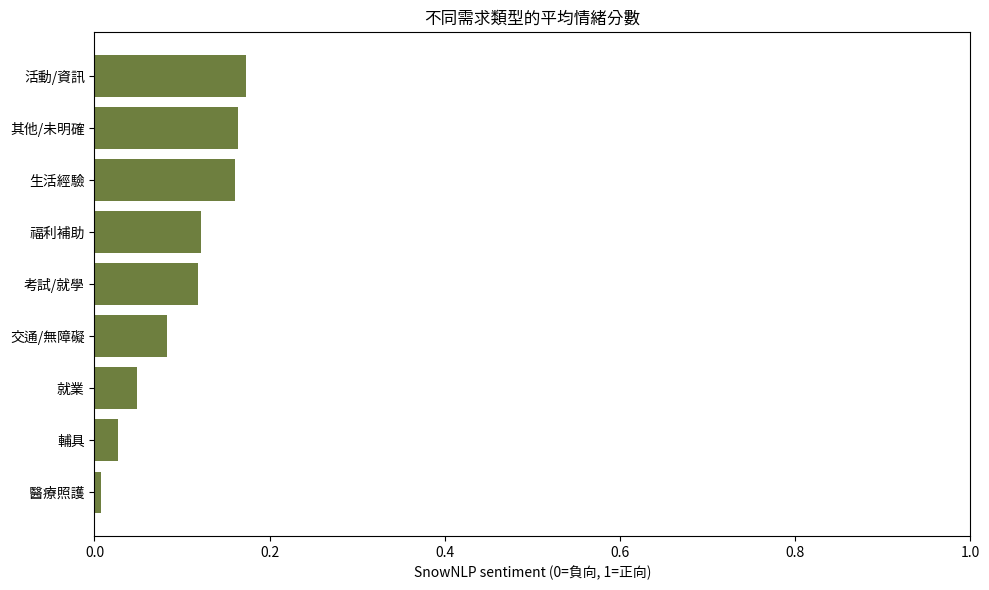

,primary_need,article_count,avg_sentiment,support_words,distress_words,avg_push_count
8,醫療照護,14,0.008,24,25,6.57
7,輔具,70,0.027,176,136,13.41
2,就業,83,0.049,84,111,12.00
0,交通/無障礙,12,0.083,24,20,5.50
6,考試/就學,26,0.118,20,18,11.88
5,福利補助,66,0.122,91,81,8.30
4,生活經驗,45,0.161,174,70,11.07
1,其他/未明確,15,0.164,10,11,10.07
3,活動/資訊,55,0.173,67,24,3.53


In [9]:
support_words = ["謝謝", "感謝", "加油", "祝福", "建議", "推薦", "可以", "幫助", "分享", "辛苦", "祝"]
distress_words = ["困難", "麻煩", "擔心", "焦慮", "不知道", "無法", "不能", "不方便", "痛苦", "問題", "煩惱"]

def snownlp_sentiment(text):
    if not SNOWNLP_AVAILABLE:
        return np.nan
    text = str(text)[:1000]
    if not text.strip():
        return np.nan
    try:
        return float(SnowNLP(text).sentiments)
    except Exception:
        return np.nan

df["snownlp_sentiment"] = df["analysis_text"].apply(snownlp_sentiment)
df["support_word_count"] = df["analysis_text"].apply(lambda t: sum(str(t).count(w) for w in support_words))
df["distress_word_count"] = df["analysis_text"].apply(lambda t: sum(str(t).count(w) for w in distress_words))

sentiment_by_need = (
    df.groupby("primary_need")
    .agg(
        article_count=("article_id", "count"),
        avg_sentiment=("snownlp_sentiment", "mean"),
        support_words=("support_word_count", "sum"),
        distress_words=("distress_word_count", "sum"),
        avg_push_count=("push_count", "mean"),
    )
    .reset_index()
)
sentiment_by_need["avg_sentiment"] = sentiment_by_need["avg_sentiment"].round(3)
sentiment_by_need["avg_push_count"] = sentiment_by_need["avg_push_count"].round(2)
sentiment_by_need.to_csv(TABLE_DIR / "sentiment_by_need.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 6))
sentiment_plot = sentiment_by_need.sort_values("avg_sentiment")
plt.barh(sentiment_plot["primary_need"], sentiment_plot["avg_sentiment"], color="#6E7F3F")
plt.title("不同需求類型的平均情緒分數")
plt.xlabel("SnowNLP sentiment (0=負向, 1=正向)")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "sentiment_by_need.png", dpi=300, bbox_inches="tight")
plt.show()

display(sentiment_by_need.sort_values("avg_sentiment"))

## 8. TF-IDF 與主題模型

詞頻可以看出常見詞，但容易被通用詞影響；TF-IDF 能找出更能區分文章的詞。主題模型則用來檢查字典分類之外，文章是否自然聚成幾個常見議題群。

,term,tfidf
833,助聽器,0.038201
3414,身障,0.034637
3410,身心障礙,0.029318
1481,工作,0.028716
1174,報名,0.024674
3155,補助,0.020775
2207,朋友,0.018556
2146,時間,0.018379
2584,申請,0.016780
3006,聽力,0.016446


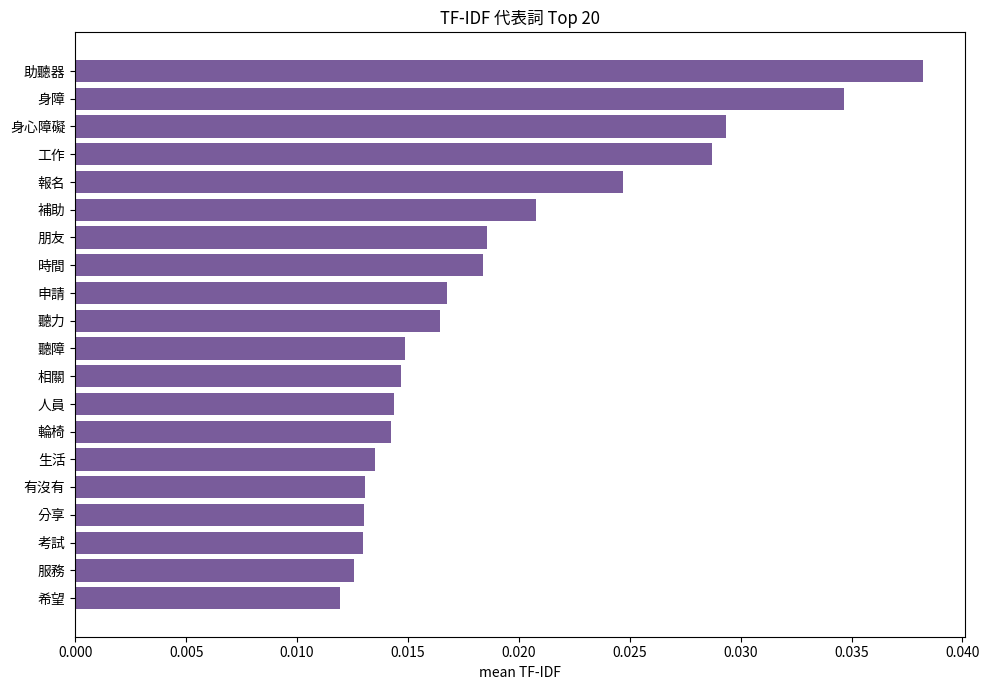

,topic_id,top_terms
0,Topic 1,工作、身心障礙、考試、身障、台電、特考、行政、人員、時間、相關、課程、招考
1,Topic 2,助聽器、聽力、聲音、申請、障礙、身心障礙、分享、肢體、經驗、調整、聽損、展期
2,Topic 3,助聽器、時間、手語、台灣、身心障礙、身障、台北、聽力、服務、社福、希望、推薦
3,Topic 4,身障、補助、朋友、生活、身心障礙、障礙者、障礙、身障者、機構、視障、時間、申請
4,Topic 5,報名、身心障礙、人員、工作、相關、甄試、資料、日期、資格、方式、時間、報考


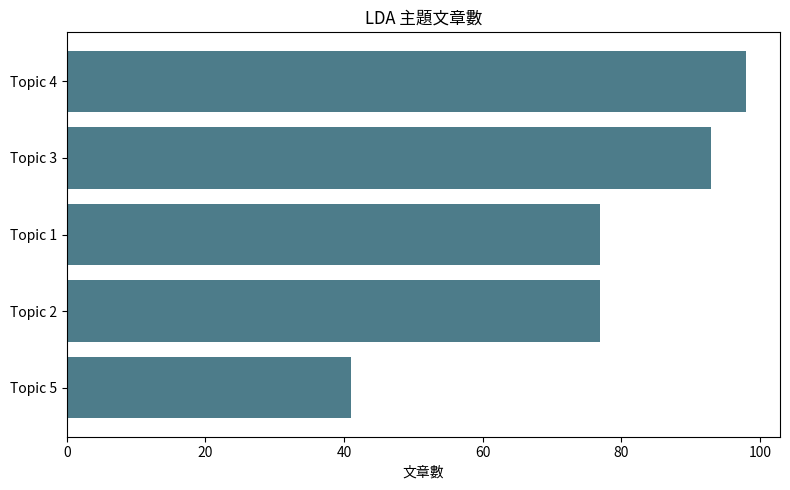

In [10]:
vector_docs = df["token_text"].fillna("")
tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=2, max_df=0.8)
try:
    tfidf = tfidf_vectorizer.fit_transform(vector_docs)
    tfidf_scores = np.asarray(tfidf.mean(axis=0)).ravel()
    tfidf_terms = pd.DataFrame({"term": tfidf_vectorizer.get_feature_names_out(), "tfidf": tfidf_scores})
    tfidf_terms = tfidf_terms.sort_values("tfidf", ascending=False).head(30)
except Exception as error:
    print(f"TF-IDF 無法建立：{error}")
    tfidf_terms = pd.DataFrame(columns=["term", "tfidf"])

tfidf_terms.to_csv(TABLE_DIR / "tfidf_top_terms.csv", index=False, encoding="utf-8-sig")
display(tfidf_terms.head(20))

if len(tfidf_terms) > 0:
    plt.figure(figsize=(10, 7))
    tfidf_plot = tfidf_terms.head(20).sort_values("tfidf")
    plt.barh(tfidf_plot["term"], tfidf_plot["tfidf"], color="#795C9B")
    plt.title("TF-IDF 代表詞 Top 20")
    plt.xlabel("mean TF-IDF")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "tfidf_top_terms.png", dpi=300, bbox_inches="tight")
    plt.show()

topic_terms_df = pd.DataFrame()
doc_topic_df = pd.DataFrame()
if df["token_text"].str.len().gt(0).sum() >= 10:
    count_vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=2, max_df=0.85)
    try:
        X = count_vectorizer.fit_transform(vector_docs)
        n_topics = min(5, max(2, len(df) // 25))
        lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method="batch", max_iter=30)
        doc_topic = lda.fit_transform(X)
        terms = np.array(count_vectorizer.get_feature_names_out())

        topic_rows = []
        for topic_idx, weights in enumerate(lda.components_):
            top_idx = weights.argsort()[::-1][:12]
            topic_rows.append(
                {
                    "topic_id": f"Topic {topic_idx + 1}",
                    "top_terms": "、".join(terms[top_idx]),
                }
            )
        topic_terms_df = pd.DataFrame(topic_rows)
        doc_topic_df = pd.DataFrame(doc_topic, columns=[f"Topic {i + 1}" for i in range(n_topics)])
        doc_topic_df["article_id"] = df["article_id"].values
        doc_topic_df["dominant_topic"] = doc_topic_df[[f"Topic {i + 1}" for i in range(n_topics)]].idxmax(axis=1)
        df["dominant_topic"] = doc_topic_df["dominant_topic"].values
    except Exception as error:
        print(f"LDA 無法建立：{error}")
        df["dominant_topic"] = "未建立"
else:
    df["dominant_topic"] = "資料不足"

topic_terms_df.to_csv(TABLE_DIR / "lda_topic_terms.csv", index=False, encoding="utf-8-sig")
doc_topic_df.to_csv(TABLE_DIR / "lda_doc_topics.csv", index=False, encoding="utf-8-sig")
display(topic_terms_df)

if "dominant_topic" in df and df["dominant_topic"].nunique() > 1:
    topic_counts = df["dominant_topic"].value_counts().reset_index()
    topic_counts.columns = ["topic", "article_count"]
    topic_counts.to_csv(TABLE_DIR / "lda_topic_counts.csv", index=False, encoding="utf-8-sig")
    plt.figure(figsize=(8, 5))
    topic_plot = topic_counts.sort_values("article_count")
    plt.barh(topic_plot["topic"], topic_plot["article_count"], color="#4D7C8A")
    plt.title("LDA 主題文章數")
    plt.xlabel("文章數")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "lda_topic_counts.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. 發文者與推文者互助網絡

社會網絡資料以 `發文者 -> 推文者` 建立有向邊。若某推文者經常回應不同發文者，可能代表他在社群中扮演資訊或經驗支持角色。這裡呈現匿名節點，不公開原始 ID。

,metric,value
0,node_count,658.00000
1,edge_count,1260.00000
2,density,0.00291
3,weak_components,7.00000


,node,in_degree,out_degree,pagerank,betweenness
9,U0406,142.0,0.0,0.012383,0.000000
56,U0393,103.0,22.0,0.009547,0.017800
14,U0135,128.0,65.0,0.008990,0.033807
23,U0414,48.0,0.0,0.007633,0.000000
274,U0397,134.0,0.0,0.006730,0.000000
270,U0394,10.0,0.0,0.005990,0.000000
259,U0125,26.0,49.0,0.005930,0.004759
41,U0154,56.0,0.0,0.005832,0.000000
65,U0090,65.0,0.0,0.005458,0.000000
17,U0486,123.0,0.0,0.004634,0.000000


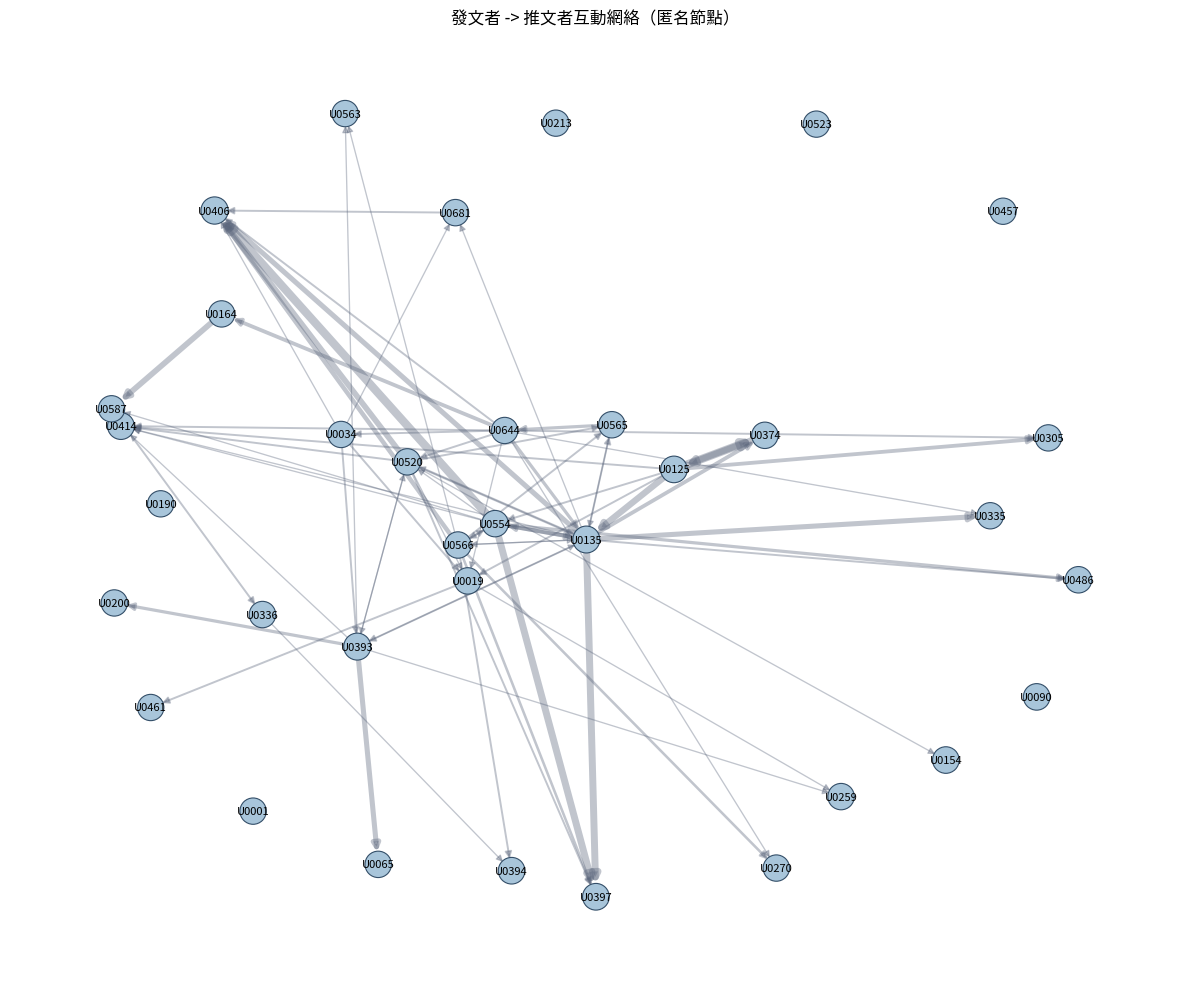

In [11]:
edge_counter = Counter()
for _, row in df.iterrows():
    source = row["author_anon"]
    for comment in row["comments_anon"]:
        target = comment.get("user_anon", "U0000")
        if not target or target == "U0000" or target == source:
            continue
        edge_counter[(source, target)] += 1

edge_df = pd.DataFrame(
    [{"source": s, "target": t, "weight": w} for (s, t), w in edge_counter.items()]
)
edge_df.to_csv(NETWORK_DIR / "interaction_edges.csv", index=False, encoding="utf-8-sig")

G = nx.DiGraph()
for _, edge in edge_df.iterrows():
    G.add_edge(edge["source"], edge["target"], weight=float(edge["weight"]))

if G.number_of_nodes() > 0:
    pagerank = nx.pagerank(G, weight="weight")
    betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)
    node_rows = []
    for node in G.nodes():
        node_rows.append(
            {
                "node": node,
                "in_degree": G.in_degree(node, weight="weight"),
                "out_degree": G.out_degree(node, weight="weight"),
                "pagerank": pagerank.get(node, 0),
                "betweenness": betweenness.get(node, 0),
            }
        )
    node_metrics = pd.DataFrame(node_rows).sort_values("pagerank", ascending=False)
else:
    node_metrics = pd.DataFrame(columns=["node", "in_degree", "out_degree", "pagerank", "betweenness"])

network_overview = pd.DataFrame(
    {
        "metric": ["node_count", "edge_count", "density", "weak_components"],
        "value": [
            G.number_of_nodes(),
            G.number_of_edges(),
            round(nx.density(G), 5) if G.number_of_nodes() > 1 else 0,
            nx.number_weakly_connected_components(G) if G.number_of_nodes() > 0 else 0,
        ],
    }
)
node_metrics.to_csv(NETWORK_DIR / "interaction_node_metrics.csv", index=False, encoding="utf-8-sig")
network_overview.to_csv(NETWORK_DIR / "interaction_network_overview.csv", index=False, encoding="utf-8-sig")

display(network_overview)
display(node_metrics.head(12))

if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
    top_nodes = set(node_metrics.head(35)["node"])
    sub = G.subgraph(top_nodes).copy()
    if sub.number_of_edges() == 0:
        top_edges = edge_df.sort_values("weight", ascending=False).head(40)
        top_nodes = set(top_edges["source"]) | set(top_edges["target"])
        sub = G.subgraph(top_nodes).copy()

    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(sub, seed=42, k=0.7, weight="weight")
    sizes = [350 + 2800 * float(node_metrics.set_index("node").loc[n, "pagerank"]) for n in sub.nodes()]
    widths = [0.5 + sub[u][v].get("weight", 1) * 0.45 for u, v in sub.edges()]
    nx.draw_networkx_nodes(sub, pos, node_size=sizes, node_color="#A8C5DA", edgecolors="#334E68", linewidths=0.8)
    nx.draw_networkx_edges(sub, pos, width=widths, alpha=0.38, arrows=True, arrowstyle="-|>", edge_color="#5C677D")
    nx.draw_networkx_labels(sub, pos, font_size=8, font_family=plt.rcParams["font.sans-serif"][0])
    plt.title("發文者 -> 推文者互動網絡（匿名節點）")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "interaction_network.png", dpi=300, bbox_inches="tight")
    plt.savefig(NETWORK_DIR / "interaction_network.png", dpi=300, bbox_inches="tight")
    plt.show()

## 10. 代表文章與可解讀結果

為了讓分析不只停留在統計數字，這段列出各需求缺口類型的代表文章標題。報告撰寫時，可以用這些標題理解每個類別背後的實際情境，但不需要揭露作者 ID。

In [12]:
representative_rows = []
for need in gap_df["primary_need"].head(5):
    subset = df[df["primary_need"] == need].sort_values(["push_count", "artDate"], ascending=[True, False]).head(5)
    for _, row in subset.iterrows():
        representative_rows.append(
            {
                "primary_need": need,
                "artDate": row["artDate"].date() if pd.notna(row["artDate"]) else "",
                "artTitle": row["artTitle"],
                "push_count": row["push_count"],
                "sentiment": row["snownlp_sentiment"],
            }
        )

representative_df = pd.DataFrame(representative_rows)
representative_df.to_csv(TABLE_DIR / "representative_gap_articles.csv", index=False, encoding="utf-8-sig")
display(representative_df)

,primary_need,artDate,artTitle,push_count,sentiment
0,就業,2026-02-23,[資訊] 迴龍國中小誠徵警衛（限持身心障礙手冊）,0,3.330669e-15
1,就業,2026-01-23,[資訊] 桃園市立迴龍國中小誠徵警衛一名,0,3.552714e-15
2,就業,2025-08-23,[資訊] BIM機電工程師身障職訓,0,4.944312e-11
3,就業,2024-12-16,[資訊] 114年財政部高雄國稅局徵才，共招94名額,0,0.000000e+00
4,就業,2024-12-16,[資訊] 台電2025僱員甄試招近千名新血 簡章12/26,0,1.355450e-05
5,活動/資訊,2026-05-14,Fw: [新聞] 聾人文化先驅顧玉山 獲文化部台灣手語貢獻獎,0,1.993393e-04
6,活動/資訊,2025-12-26,[閒聊] 徵求蔡依林大巨蛋演唱會身障票兩張,0,9.042416e-01
7,活動/資訊,2025-12-08,[閒聊] 求蔡依林演唱會身障票2張(含陪同),0,2.621980e-02
8,活動/資訊,2025-11-12,[資訊] 社會在走，交友要懂—身障女性交友及網路安全培力,0,3.364681e-08
9,活動/資訊,2025-11-06,[讓票] SUPER JUNIOR <SS10> in TAIPEI (愛心票),0,1.296412e-10


## 11. 需求卡點質性標註

前面的分類回答「哪一類需求多、哪一類回應少」，但還不能說明使用者真正卡在哪裡。因此這段新增一層可解釋的質性標註：針對每篇文章辨識具體卡點，例如資格流程不明、找不到窗口、需要同儕經驗推薦、職場歧視壓力、交通環境限制等。

這不是人工訪談，也不能取代訪談；它的功能是把社群文字從「主題分類」推進到「問題情境」，讓報告更接近需求理解。

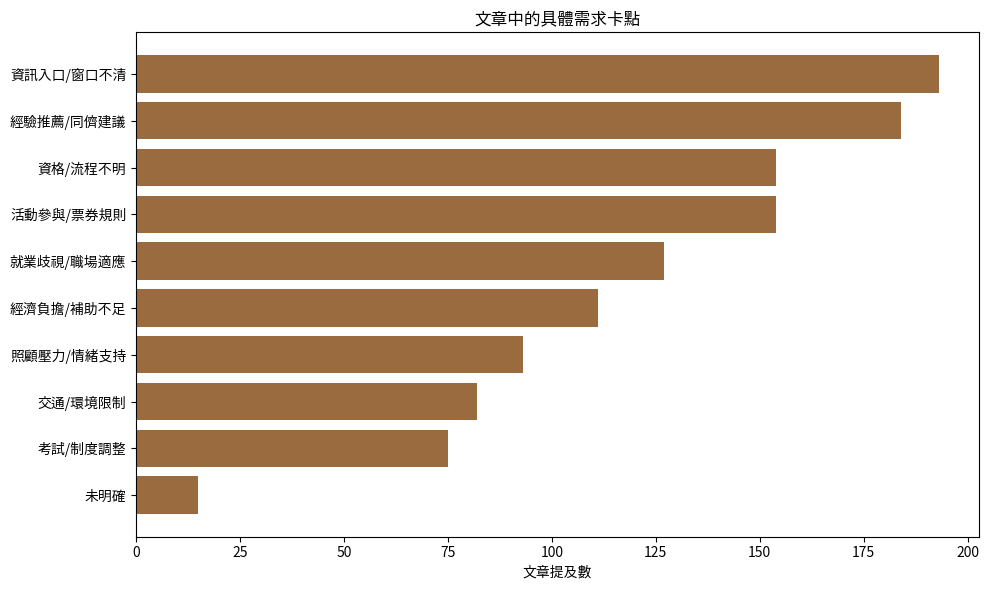

,pain_point,article_mentions
9,資訊入口/窗口不清,193
6,經驗推薦/同儕建議,184
3,活動參與/票券規則,154
8,資格/流程不明,154
1,就業歧視/職場適應,127
5,經濟負擔/補助不足,111
4,照顧壓力/情緒支持,93
0,交通/環境限制,82
7,考試/制度調整,75
2,未明確,15


,primary_need,pain_point,article_mentions
1,就業,就業歧視/職場適應,73
9,就業,資訊入口/窗口不清,62
8,就業,資格/流程不明,40
6,就業,經驗推薦/同儕建議,38
7,就業,考試/制度調整,38
3,就業,活動參與/票券規則,36
4,就業,照顧壓力/情緒支持,20
5,就業,經濟負擔/補助不足,20
0,就業,交通/環境限制,15
2,就業,未明確,1


,primary_need,artDate,artTitle,push_count,primary_pain_point,all_pain_points,evidence_terms
0,就業,2024-12-12,[資訊] 臺北市114 年度清潔維護業務短期就業,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、經濟負擔/補助不足、就業歧視/職場適應、交通/環境限制、活動參與/票券規則,"{""資格/流程不明"": [""資格"", ""申請"", ""流程"", ""文件"", ""證明""], ""資訊入口/窗口不清"": [""電話"", ""查詢"", ""資訊""], ""經濟負擔/補助不足"": [""津貼"", ""負擔"", ""低收"", ""中低收"", ..."
1,就業,2021-08-15,Re: [問題] 身心特考的工作有比一般外面的工作輕鬆嘛,0,資訊入口/窗口不清,資訊入口/窗口不清、經驗推薦/同儕建議、經濟負擔/補助不足、就業歧視/職場適應、交通/環境限制、考試/制度調整、照顧壓力/情緒支持,"{""資訊入口/窗口不清"": [""窗口"", ""單位"", ""電話""], ""經驗推薦/同儕建議"": [""經驗"", ""分享"", ""選擇"", ""比較""], ""經濟負擔/補助不足"": [""負擔""], ""就業歧視/職場適應"": [""同事"", ""工..."
2,就業,2022-10-25,[資訊] 達觀國中小誠徵綜合行政幹事(具身障資格),0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、就業歧視/職場適應、交通/環境限制、考試/制度調整、活動參與/票券規則,"{""資格/流程不明"": [""資格"", ""文件"", ""證明"", ""規定""], ""資訊入口/窗口不清"": [""電話"", ""資訊""], ""就業歧視/職場適應"": [""面試"", ""工作"", ""職缺"", ""職務"", ""錄取""], ""交通/環境..."
3,就業,2025-08-23,[資訊] BIM機電工程師身障職訓,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、經驗推薦/同儕建議、經濟負擔/補助不足、就業歧視/職場適應、交通/環境限制、活動參與/票券規則,"{""資格/流程不明"": [""流程"", ""期限""], ""資訊入口/窗口不清"": [""資訊""], ""經驗推薦/同儕建議"": [""經驗"", ""選擇""], ""經濟負擔/補助不足"": [""費用""], ""就業歧視/職場適應"": [""職場"", ""..."
4,就業,2022-09-30,[資訊] 警專圖書館徵學生(身障生)工讀,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、經驗推薦/同儕建議、就業歧視/職場適應、考試/制度調整,"{""資格/流程不明"": [""資格"", ""文件"", ""證明"", ""手冊""], ""資訊入口/窗口不清"": [""電話"", ""資訊""], ""經驗推薦/同儕建議"": [""經驗""], ""就業歧視/職場適應"": [""面試"", ""工作"", ""錄取""..."
5,就業,2021-10-31,[資訊] 國家災害防救科技中心舉辦工作坊報名中,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、經驗推薦/同儕建議、就業歧視/職場適應、考試/制度調整、活動參與/票券規則,"{""資格/流程不明"": [""證明"", ""手冊""], ""資訊入口/窗口不清"": [""電話"", ""資訊""], ""經驗推薦/同儕建議"": [""經驗"", ""選擇""], ""就業歧視/職場適應"": [""職場"", ""工作"", ""錄取""], ""考試..."
6,就業,2022-04-16,Fw: [情報] 持五倍券、好食券到微光庇護工場消費有優惠,0,資訊入口/窗口不清,資訊入口/窗口不清、經濟負擔/補助不足、交通/環境限制,"{""資訊入口/窗口不清"": [""電話"", ""資訊""], ""經濟負擔/補助不足"": [""金額""], ""交通/環境限制"": [""無障礙""]}"
7,就業,2021-09-23,[資訊] 交通部臺灣鐵路管理局 身心障礙障徵才,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、經驗推薦/同儕建議、就業歧視/職場適應、交通/環境限制、考試/制度調整、活動參與/票券規則,"{""資格/流程不明"": [""文件"", ""證明"", ""手冊"", ""期限""], ""資訊入口/窗口不清"": [""電話"", ""網站"", ""資訊""], ""經驗推薦/同儕建議"": [""經驗""], ""就業歧視/職場適應"": [""面試"", ""工作""..."
8,就業,2024-10-21,Fw: [情報] 中華郵政 身障 半日內勤約聘報名,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、考試/制度調整、活動參與/票券規則,"{""資格/流程不明"": [""申請"", ""規定""], ""資訊入口/窗口不清"": [""電話"", ""查詢""], ""考試/制度調整"": [""應考""], ""活動參與/票券規則"": [""報名""]}"
9,就業,2021-10-22,[資訊] 台大醫院護理部助理員(身心障礙人員)徵才,0,資格/流程不明,資格/流程不明、資訊入口/窗口不清、就業歧視/職場適應、活動參與/票券規則,"{""資格/流程不明"": [""資格"", ""手冊"", ""規定""], ""資訊入口/窗口不清"": [""電話"", ""資訊""], ""就業歧視/職場適應"": [""面試"", ""工作""], ""活動參與/票券規則"": [""報名""]}"


In [13]:
pain_point_keywords = {
    "資格/流程不明": ["資格", "申請", "流程", "怎麼辦", "怎麼申請", "如何申請", "需要什麼", "文件", "證明", "鑑定", "手冊", "期限", "規定"],
    "資訊入口/窗口不清": ["哪裡", "窗口", "單位", "承辦", "電話", "網站", "查詢", "資訊", "找不到", "不知道問誰", "客服"],
    "經驗推薦/同儕建議": ["推薦", "有人用過", "經驗", "分享", "心得", "請益", "建議", "選擇", "比較", "廠商", "品牌"],
    "經濟負擔/補助不足": ["費用", "價格", "自費", "補助", "津貼", "金額", "負擔", "低收", "中低收", "便宜", "預算"],
    "就業歧視/職場適應": ["歧視", "面試", "職場", "同事", "主管", "工作", "求職", "薪水", "職缺", "職務", "錄取", "離職"],
    "交通/環境限制": ["交通", "無障礙", "復康巴士", "捷運", "公車", "停車", "坡道", "電梯", "輪椅", "行動不便", "出門"],
    "考試/制度調整": ["考試", "國考", "特考", "延長", "電腦作答", "試場", "應考", "就學", "學校", "學生"],
    "照顧壓力/情緒支持": ["壓力", "焦慮", "擔心", "痛苦", "困擾", "照顧", "家人", "陪伴", "不知道怎麼辦", "心情", "辛苦"],
    "活動參與/票券規則": ["活動", "票", "愛心票", "陪同", "演唱會", "講座", "課程", "報名", "問卷", "受訪"],
}

def identify_pain_points(text):
    hits = []
    evidence = {}
    text = str(text)
    for label, keywords in pain_point_keywords.items():
        matched = [kw for kw in keywords if kw in text]
        if matched:
            hits.append(label)
            evidence[label] = matched[:5]
    if not hits:
        return ["未明確"], {"未明確": []}
    return hits, evidence

pain_results = df["analysis_text"].apply(identify_pain_points)
df["pain_points"] = pain_results.apply(lambda x: x[0])
df["pain_points_json"] = df["pain_points"].apply(lambda xs: json.dumps(xs, ensure_ascii=False))
df["pain_evidence_json"] = pain_results.apply(lambda x: json.dumps(x[1], ensure_ascii=False))
df["primary_pain_point"] = df["pain_points"].apply(lambda xs: xs[0] if xs else "未明確")

pain_rows = []
for _, row in df.iterrows():
    for pain_point in row["pain_points"]:
        pain_rows.append(
            {
                "article_id": row["article_id"],
                "primary_need": row["primary_need"],
                "pain_point": pain_point,
                "push_count": row["push_count"],
                "artDate": row["artDate"],
            }
        )
pain_df = pd.DataFrame(pain_rows)
pain_df.to_csv(TABLE_DIR / "qualitative_pain_points_long.csv", index=False, encoding="utf-8-sig")

pain_summary = (
    pain_df.groupby(["primary_need", "pain_point"])
    .agg(
        article_mentions=("article_id", "nunique"),
        avg_push_count=("push_count", "mean"),
    )
    .reset_index()
)
pain_summary["avg_push_count"] = pain_summary["avg_push_count"].round(2)
pain_summary = pain_summary.sort_values(["primary_need", "article_mentions"], ascending=[True, False])
pain_summary.to_csv(TABLE_DIR / "qualitative_pain_point_summary.csv", index=False, encoding="utf-8-sig")

overall_pain = (
    pain_df.groupby("pain_point")
    .agg(article_mentions=("article_id", "nunique"))
    .reset_index()
    .sort_values("article_mentions", ascending=False)
)
overall_pain.to_csv(TABLE_DIR / "qualitative_pain_point_overall.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 6))
pain_plot = overall_pain.head(10).sort_values("article_mentions")
plt.barh(pain_plot["pain_point"], pain_plot["article_mentions"], color="#9A6B3F")
plt.title("文章中的具體需求卡點")
plt.xlabel("文章提及數")
plt.tight_layout()
plt.savefig(FIG_DIR / "qualitative_pain_point_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

top_gap_needs = gap_df["primary_need"].head(3).tolist()
qualitative_case_rows = []
for need in top_gap_needs:
    subset = (
        df[df["primary_need"] == need]
        .assign(reply_rank=lambda x: x["push_count"].rank(method="first", ascending=True))
        .sort_values(["push_count", "text_length", "artDate"], ascending=[True, False, False])
        .head(10)
    )
    for _, row in subset.iterrows():
        qualitative_case_rows.append(
            {
                "primary_need": need,
                "artDate": row["artDate"].date() if pd.notna(row["artDate"]) else "",
                "artTitle": row["artTitle"],
                "push_count": row["push_count"],
                "primary_pain_point": row["primary_pain_point"],
                "all_pain_points": "、".join(row["pain_points"]),
                "evidence_terms": row["pain_evidence_json"],
            }
        )

qualitative_cases_df = pd.DataFrame(qualitative_case_rows)
qualitative_cases_df.to_csv(TABLE_DIR / "qualitative_gap_cases.csv", index=False, encoding="utf-8-sig")

gap_pain_summary = (
    pain_df[pain_df["primary_need"].isin(top_gap_needs)]
    .groupby(["primary_need", "pain_point"])
    .agg(article_mentions=("article_id", "nunique"))
    .reset_index()
    .sort_values(["primary_need", "article_mentions"], ascending=[True, False])
)
gap_pain_summary.to_csv(TABLE_DIR / "qualitative_gap_pain_summary.csv", index=False, encoding="utf-8-sig")

display(overall_pain.head(10))
display(gap_pain_summary)
display(qualitative_cases_df)

clean_export = df.drop(columns=["comments", "comments_anon"], errors="ignore").copy()
clean_export["tokens_json"] = df["tokens"].apply(lambda xs: json.dumps(xs, ensure_ascii=False))
clean_export.to_csv(CLEAN_CSV, index=False, encoding="utf-8-sig")

## 12. 衛福部公開統計與社群需求對照

PTT 文章能呈現微觀求助情境，但不能代表全體身心障礙者。為了讓研究更有意義，本段加入衛福部公開統計作為宏觀背景：身心障礙人口結構、生活補助與輔具補助。這些資料不直接解釋個別發文者，而是用來對照社群高頻需求是否落在正式服務常見領域。

主要資料來源：

- 衛福部統計處：https://dep.mohw.gov.tw/DOS/mp-113.html
- 社會福利公務統計一覽表：https://dep.mohw.gov.tw/DOS/cp-5337-86102-113.html
- 身心障礙服務說明：https://www.mohw.gov.tw/cp-88-235-1.html

讀取既有政府資料：2_3_1_disability_population_by_category_city.ods
讀取既有政府資料：2_3_10_living_allowance.xlsx
讀取既有政府資料：2_3_11_assistive_device_subsidy.xlsx


,source_key,title,url,local_file,downloaded
0,population_by_category_city,2.3.1 身心障礙者人數按類別及縣市別分,https://www.mohw.gov.tw/dl-69411-96eddda2-305c-4c30-acc7-b9a706d7a22f.html,/Users/ye/Desktop/碩士/6-二下/社群媒體分析/8-期末專案/ptt_disabled_project/data/gov/2_3_1_disability_population_by_category_city.ods,True
1,living_allowance,2.3.10 身心障礙者生活補助,https://www.mohw.gov.tw/dl-69248-fa9f6837-13de-4a6d-985b-7ef4e654bff2.html,/Users/ye/Desktop/碩士/6-二下/社群媒體分析/8-期末專案/ptt_disabled_project/data/gov/2_3_10_living_allowance.xlsx,True
2,assistive_device_subsidy,2.3.11 身心障礙者生活輔具補助,https://www.mohw.gov.tw/dl-69250-7099a424-9de8-4307-bd34-cdbbbc325e0d.html,/Users/ye/Desktop/碩士/6-二下/社群媒體分析/8-期末專案/ptt_disabled_project/data/gov/2_3_11_assistive_device_subsidy.xlsx,True


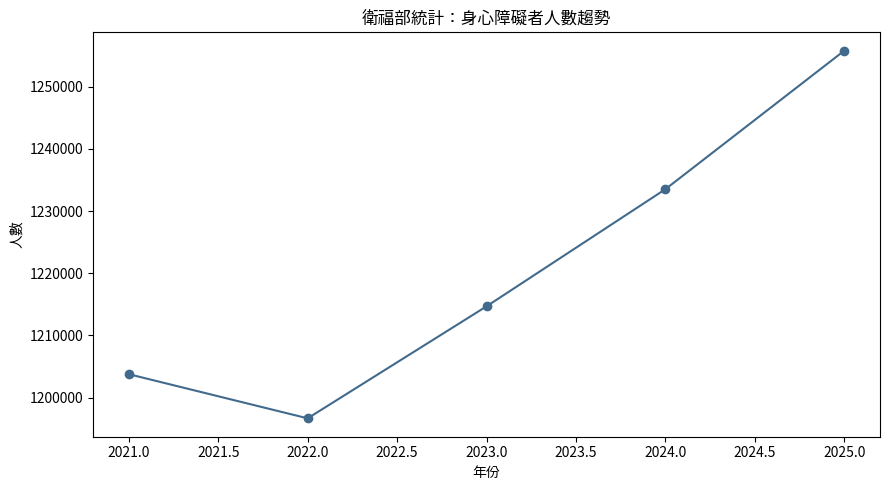

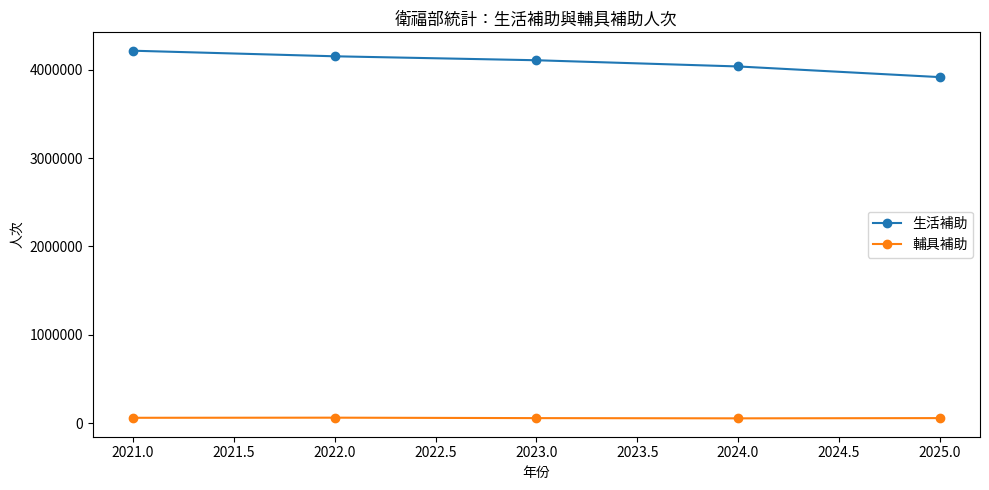

,primary_need,article_count,avg_push_count,zero_reply_ratio,gap_score,government_context,dominant_pain_point,report_insight
2,就業,83,12.00,0.325,0.663,可對照身心障礙就業服務與職務再設計，社群討論可補足職場經驗與面試細節。,就業歧視/職場適應,優先解讀：高需求或低回應，適合在報告中討論資訊缺口。
3,活動/資訊,55,3.53,0.436,0.606,多為活動、問卷、票券與公告，適合檢查資訊傳播是否集中在少數管道。,活動參與/票券規則,優先解讀：高需求或低回應，適合在報告中討論資訊缺口。
5,福利補助,66,8.30,0.197,0.554,對照 2.3.10 生活補助：正式制度存在，但 PTT 仍常出現資格、流程、證明與申請情境問題。,資格/流程不明,優先解讀：高需求或低回應，適合在報告中討論資訊缺口。
7,輔具,70,13.41,0.157,0.511,對照 2.3.11 輔具補助與衛福部輔具服務：社群需求多半不是只有是否有補助，而是選擇、廠商、申請與使用經驗。,經驗推薦/同儕建議,優先解讀：高需求或低回應，適合在報告中討論資訊缺口。
4,生活經驗,45,11.07,0.267,0.404,較偏日常適應與照顧關係，政府統計只能提供背景，社群文本更能呈現生活脈絡。,經驗推薦/同儕建議,優先解讀：高需求或低回應，適合在報告中討論資訊缺口。
6,考試/就學,26,11.88,0.308,0.282,政府統計較難直接對照，顯示教育考試調整屬於跨部門資訊缺口，需要更明確的情境式 FAQ。,考試/制度調整,輔助解讀：可作為背景或次要需求。
0,交通/無障礙,12,5.50,0.250,0.243,對照衛福部復康巴士與無障礙相關服務：若社群發文多但回應少，代表在地可用性與查找路徑可能比制度名稱更重要。,交通/環境限制,輔助解讀：可作為背景或次要需求。
1,其他/未明確,15,10.07,0.267,0.217,需求較分散，適合回到原文標題檢查是否需要調整字典分類。,未明確,輔助解讀：可作為背景或次要需求。
8,醫療照護,14,6.57,0.071,0.191,可對照人口類別與長照/醫療服務，但 PTT 文章多為個案情境，不能直接推論醫療需求規模。,經驗推薦/同儕建議,輔助解讀：可作為背景或次要需求。


In [14]:
def download_gov_file(source_key):
    source = GOV_SOURCES[source_key]
    path = DATA_GOV_DIR / source["filename"]
    if path.exists() and path.stat().st_size > 0:
        print(f"讀取既有政府資料：{path.name}")
        return path
    response = session.get(source["url"], timeout=45)
    response.raise_for_status()
    path.write_bytes(response.content)
    print(f"已下載政府資料：{source['title']} -> {path.name}")
    return path

def parse_number(value):
    text = str(value or "").strip().replace(",", "")
    if not text:
        return np.nan
    match = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(match.group(0)) if match else np.nan

def parse_year(value):
    text = str(value or "").strip()
    match = re.search(r"(\d{3})年,?(\d{4})?", text)
    if match:
        return int(match.group(2)) if match.group(2) else int(match.group(1)) + 1911
    if re.fullmatch(r"\d{3}", text):
        return int(text) + 1911
    return np.nan

def xlsx_column_index(cell_ref):
    letters = re.sub(r"\d", "", cell_ref or "")
    index = 0
    for char in letters:
        index = index * 26 + (ord(char.upper()) - ord("A") + 1)
    return max(index - 1, 0)

def read_xlsx_rows(path, sheet_path="xl/worksheets/sheet1.xml"):
    with ZipFile(path) as zf:
        ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in root.findall("a:si", ns):
                shared_strings.append("".join(t.text or "" for t in si.findall(".//a:t", ns)))

        root = ET.fromstring(zf.read(sheet_path))
        rows = []
        for row in root.findall(".//a:sheetData/a:row", ns):
            values = {}
            max_col = 0
            for cell in row.findall("a:c", ns):
                idx = xlsx_column_index(cell.attrib.get("r", "A1"))
                max_col = max(max_col, idx)
                cell_type = cell.attrib.get("t")
                value_node = cell.find("a:v", ns)
                if cell_type == "inlineStr":
                    value = "".join(t.text or "" for t in cell.findall(".//a:t", ns))
                elif value_node is None:
                    value = ""
                else:
                    value = value_node.text or ""
                    if cell_type == "s" and value:
                        value = shared_strings[int(value)]
                values[idx] = value
            rows.append([values.get(i, "") for i in range(max_col + 1)])
        return rows

def read_ods_rows(path, table_index=0):
    ns = {
        "table": "urn:oasis:names:tc:opendocument:xmlns:table:1.0",
        "text": "urn:oasis:names:tc:opendocument:xmlns:text:1.0",
    }
    with ZipFile(path) as zf:
        root = ET.fromstring(zf.read("content.xml"))
    tables = root.findall(".//table:table", ns)
    if not tables:
        return []
    rows = []
    for row in tables[table_index].findall("table:table-row", ns):
        values = []
        for cell in row.findall("table:table-cell", ns):
            repeat = int(cell.attrib.get("{urn:oasis:names:tc:opendocument:xmlns:table:1.0}number-columns-repeated", "1"))
            text = "".join(t.text or "" for t in cell.findall(".//text:p", ns))
            values.extend([text] * min(repeat, 80))
        rows.append(values)
    return rows

gov_downloads = []
for source_key in GOV_SOURCES:
    try:
        path = download_gov_file(source_key)
        gov_downloads.append(
            {
                "source_key": source_key,
                "title": GOV_SOURCES[source_key]["title"],
                "url": GOV_SOURCES[source_key]["url"],
                "local_file": str(path),
                "downloaded": True,
            }
        )
    except Exception as error:
        gov_downloads.append(
            {
                "source_key": source_key,
                "title": GOV_SOURCES[source_key]["title"],
                "url": GOV_SOURCES[source_key]["url"],
                "local_file": "",
                "downloaded": False,
                "error": repr(error),
            }
        )

gov_source_df = pd.DataFrame(gov_downloads)
gov_source_df.to_csv(TABLE_DIR / "gov_source_manifest.csv", index=False, encoding="utf-8-sig")
display(gov_source_df)

population_rows = []
pop_path = DATA_GOV_DIR / GOV_SOURCES["population_by_category_city"]["filename"]
if pop_path.exists():
    for row in read_ods_rows(pop_path, table_index=0):
        year = parse_year(row[0] if len(row) > 0 else "")
        if pd.notna(year) and 2021 <= int(year) <= 2026:
            population_rows.append(
                {
                    "year": int(year),
                    "disabled_total": parse_number(row[1] if len(row) > 1 else ""),
                    "disabled_male": parse_number(row[2] if len(row) > 2 else ""),
                    "disabled_female": parse_number(row[3] if len(row) > 3 else ""),
                    "mental_nervous": parse_number(row[4] if len(row) > 4 else ""),
                    "sensory_pain": parse_number(row[5] if len(row) > 5 else ""),
                    "movement_related": parse_number(row[10] if len(row) > 10 else ""),
                    "multi_classification": parse_number(row[12] if len(row) > 12 else ""),
                    "disabled_rate_total": parse_number(row[14] if len(row) > 14 else ""),
                }
            )
gov_population_df = pd.DataFrame(population_rows).dropna(subset=["disabled_total"], how="all")
gov_population_df.to_csv(TABLE_DIR / "gov_disability_population_summary.csv", index=False, encoding="utf-8-sig")

subsidy_rows = []
for source_key, measure_name in [
    ("living_allowance", "生活補助"),
    ("assistive_device_subsidy", "輔具補助"),
]:
    path = DATA_GOV_DIR / GOV_SOURCES[source_key]["filename"]
    if not path.exists():
        continue
    for row in read_xlsx_rows(path):
        year = parse_year(row[0] if len(row) > 0 else "")
        if pd.notna(year) and 2021 <= int(year) <= 2026:
            person_times = parse_number(row[1] if len(row) > 1 else "")
            amount_ntd_thousand = parse_number(row[4] if len(row) > 4 else "")
            if pd.notna(person_times) or pd.notna(amount_ntd_thousand):
                subsidy_rows.append(
                    {
                        "source_key": source_key,
                        "measure": measure_name,
                        "year": int(year),
                        "person_times": person_times,
                        "amount_ntd_thousand": amount_ntd_thousand,
                    }
                )
gov_subsidy_df = pd.DataFrame(subsidy_rows)
gov_subsidy_df.to_csv(TABLE_DIR / "gov_subsidy_summary.csv", index=False, encoding="utf-8-sig")

if len(gov_population_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(gov_population_df["year"], gov_population_df["disabled_total"], marker="o", color="#426A8C")
    plt.title("衛福部統計：身心障礙者人數趨勢")
    plt.xlabel("年份")
    plt.ylabel("人數")
    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "gov_disability_population_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

if len(gov_subsidy_df) > 0:
    plt.figure(figsize=(10, 5))
    for measure, sub in gov_subsidy_df.groupby("measure"):
        annual = sub.dropna(subset=["person_times"]).sort_values("year")
        plt.plot(annual["year"], annual["person_times"], marker="o", label=measure)
    plt.title("衛福部統計：生活補助與輔具補助人次")
    plt.xlabel("年份")
    plt.ylabel("人次")
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "gov_subsidy_person_times.png", dpi=300, bbox_inches="tight")
    plt.show()

    amount_pivot = gov_subsidy_df.pivot_table(index="year", columns="measure", values="amount_ntd_thousand", aggfunc="first").reset_index()
    amount_pivot.to_csv(TABLE_DIR / "gov_subsidy_amount_pivot.csv", index=False, encoding="utf-8-sig")

need_for_alignment = gap_df[["primary_need", "article_count", "avg_push_count", "zero_reply_ratio", "gap_score"]].copy()
service_map = {
    "福利補助": "對照 2.3.10 生活補助：正式制度存在，但 PTT 仍常出現資格、流程、證明與申請情境問題。",
    "輔具": "對照 2.3.11 輔具補助與衛福部輔具服務：社群需求多半不是只有是否有補助，而是選擇、廠商、申請與使用經驗。",
    "交通/無障礙": "對照衛福部復康巴士與無障礙相關服務：若社群發文多但回應少，代表在地可用性與查找路徑可能比制度名稱更重要。",
    "考試/就學": "政府統計較難直接對照，顯示教育考試調整屬於跨部門資訊缺口，需要更明確的情境式 FAQ。",
    "就業": "可對照身心障礙就業服務與職務再設計，社群討論可補足職場經驗與面試細節。",
    "醫療照護": "可對照人口類別與長照/醫療服務，但 PTT 文章多為個案情境，不能直接推論醫療需求規模。",
    "生活經驗": "較偏日常適應與照顧關係，政府統計只能提供背景，社群文本更能呈現生活脈絡。",
    "活動/資訊": "多為活動、問卷、票券與公告，適合檢查資訊傳播是否集中在少數管道。",
    "其他/未明確": "需求較分散，適合回到原文標題檢查是否需要調整字典分類。",
}
need_for_alignment["government_context"] = need_for_alignment["primary_need"].map(service_map).fillna("可作為社群需求觀察，但目前沒有直接政府統計對照。")
dominant_pain_by_need = (
    pain_summary.sort_values(["primary_need", "article_mentions"], ascending=[True, False])
    .drop_duplicates("primary_need")
    .set_index("primary_need")["pain_point"]
    .to_dict()
)
need_for_alignment["dominant_pain_point"] = need_for_alignment["primary_need"].map(dominant_pain_by_need).fillna("未明確")
need_for_alignment["report_insight"] = np.where(
    need_for_alignment["gap_score"] >= need_for_alignment["gap_score"].median(),
    "優先解讀：高需求或低回應，適合在報告中討論資訊缺口。",
    "輔助解讀：可作為背景或次要需求。",
)
need_for_alignment.to_csv(TABLE_DIR / "ptt_need_government_alignment.csv", index=False, encoding="utf-8-sig")
display(need_for_alignment)

## 13. 驗證與期末報告摘要

這一段檢查必要輸出是否存在，並產生可直接放入報告或簡報的中文摘要。

In [15]:
required_figures = [
    FIG_DIR / "monthly_article_counts.png",
    FIG_DIR / "need_category_distribution.png",
    FIG_DIR / "need_gap_score.png",
    FIG_DIR / "sentiment_by_need.png",
    FIG_DIR / "interaction_network.png",
    FIG_DIR / "qualitative_pain_point_distribution.png",
    FIG_DIR / "gov_disability_population_trend.png",
    FIG_DIR / "gov_subsidy_person_times.png",
]
validation = {
    "raw_csv_exists": RAW_CSV.exists(),
    "clean_csv_exists": CLEAN_CSV.exists(),
    "no_duplicate_artUrl": int(df["artUrl"].duplicated().sum()) == 0,
    "dates_in_window": bool(df["artDate"].between(START_DATE, REFERENCE_DATE + pd.Timedelta(days=1), inclusive="both").all()),
    "required_figures_exist": all(path.exists() for path in required_figures),
    "article_count_greater_than_3y_cache_210": len(raw_df.drop_duplicates("artUrl")) > 210,
    "gov_files_downloaded": bool(gov_source_df["downloaded"].all()) if "downloaded" in gov_source_df else False,
    "gov_population_parsed": len(gov_population_df) > 0,
    "gov_subsidy_parsed": len(gov_subsidy_df) > 0,
    "gov_alignment_table_exists": (TABLE_DIR / "ptt_need_government_alignment.csv").exists(),
    "qualitative_pain_points_exist": (TABLE_DIR / "qualitative_gap_cases.csv").exists(),
}
validation_df = pd.DataFrame({"check": list(validation.keys()), "passed": list(validation.values())})
validation_df.to_csv(TABLE_DIR / "validation_checks.csv", index=False, encoding="utf-8-sig")
display(validation_df)

top_need = need_summary.iloc[0]
top_gap = gap_df.iloc[0]
top_node = node_metrics.iloc[0] if len(node_metrics) else pd.Series({"node": "無", "pagerank": 0, "in_degree": 0, "out_degree": 0})
low_sent = sentiment_by_need.sort_values("avg_sentiment").iloc[0]
high_zero = gap_df.sort_values("zero_reply_ratio", ascending=False).iloc[0]
latest_population = gov_population_df.dropna(subset=["disabled_total"]).sort_values("year").tail(1)
latest_population_text = "政府人口資料未成功解析"
if len(latest_population) > 0:
    pop_row = latest_population.iloc[0]
    latest_population_text = f'{int(pop_row["year"])} 年身心障礙者人數約 {int(pop_row["disabled_total"]):,} 人，身心障礙人口比率約 {pop_row["disabled_rate_total"]:.2f}%'

subsidy_latest = gov_subsidy_df.dropna(subset=["person_times"]).sort_values("year")
subsidy_text_parts = []
for measure, sub in subsidy_latest.groupby("measure"):
    row = sub.tail(1).iloc[0]
    subsidy_text_parts.append(f'{measure}於 {int(row["year"])} 年約 {int(row["person_times"]):,} 人次')
subsidy_context_text = "；".join(subsidy_text_parts) if subsidy_text_parts else "補助資料未成功解析"

top_alignment = need_for_alignment.iloc[0] if len(need_for_alignment) else pd.Series({"government_context": "無對照資料"})
top_pain = overall_pain.iloc[0] if len(overall_pain) else pd.Series({"pain_point": "未明確", "article_mentions": 0})
top_gap_pain = (
    gap_pain_summary[gap_pain_summary["primary_need"] == top_gap["primary_need"]].head(1)
    if len(gap_pain_summary) else pd.DataFrame()
)
if len(top_gap_pain) > 0:
    top_gap_pain_text = f'{top_gap_pain.iloc[0]["pain_point"]}（{int(top_gap_pain.iloc[0]["article_mentions"])} 篇提及）'
else:
    top_gap_pain_text = "未明確"

summary_md = f'''
### 期末報告摘要

本研究分析 PTT Disabled 板於 **{START_DATE.date()} 至 {REFERENCE_DATE.date()}** 的公開討論文章，共取得 **{len(df):,} 篇非公告文章**、**{int(df["push_count"].sum()):,} 則推文**，並加入衛福部身心障礙公開統計作為宏觀背景。研究目的在於觀察身心障礙相關議題中，哪些需求會被帶到非正式社群中求助，以及哪些主題可能呈現「高需求但低回應」的資訊缺口。

**RQ1 主要需求類型：** 文章數最多的需求類型是 **{top_need["primary_need"]}**，共有 **{int(top_need["article_count"])} 篇**，顯示該類議題是 Disabled 板近五年最常被提出的討論方向。整體而言，板上討論不只包含情緒分享，也包含具體資源、申請流程、輔具選擇、就業考試與活動資訊等實務需求。

**RQ2 需求缺口：** 依據文章數、平均推文數與零回覆比例計算後，缺口分數最高的是 **{top_gap["primary_need"]}**。此類議題同時具備較高發文量與相對有限的回應，代表使用者經常提出相關問題，但社群未必能提供足夠回覆。另一個值得注意的指標是 **{high_zero["primary_need"]}** 的零回覆比例較高，可能表示此類問題較個人化、資訊較難取得，或需要正式機構提供更清楚的說明。

**RQ3 情緒與語氣：** 平均情緒分數最低的需求類型是 **{low_sent["primary_need"]}**，表示相關文章更常帶有困擾、疑問或負向語氣。這不代表發文者本身狀態，而是反映該類需求在文字表達上更接近「問題尚未被解決」。

**RQ4 互助網絡：** 發文者與推文者互動網絡共有 **{G.number_of_nodes():,} 個匿名節點**、**{G.number_of_edges():,} 條互動邊**。PageRank 最高的節點為 **{top_node["node"]}**，其加權入度為 **{top_node["in_degree"]:.0f}**、加權出度為 **{top_node["out_degree"]:.0f}**。若少數節點明顯居中，表示社群資訊支持可能仰賴少數活躍回覆者；若節點分散，則代表互助較由多數使用者共同承擔。

**RQ5 政府公開統計對照：** 衛福部公開統計顯示，{latest_population_text}；補助資料方面，{subsidy_context_text}。這些統計說明正式制度與服務確實存在，但 PTT 文章呈現的是更微觀的使用問題，例如「資格怎麼判斷」、「流程怎麼走」、「輔具怎麼選」、「不同情境能不能申請」。以缺口分數最高的 **{top_gap["primary_need"]}** 為例，對照解讀為：{top_alignment["government_context"]}

**RQ6 具體需求卡點：** 為避免只停留在「文章很多」的層次，本研究進一步用質性卡點字典標註文章內容。整體最常見的卡點是 **{top_pain["pain_point"]}**，共有 **{int(top_pain["article_mentions"])} 篇**提及；在缺口最高的 **{top_gap["primary_need"]}** 類別中，最常見卡點為 **{top_gap_pain_text}**。這表示社群需求不只是單一主題，而是包含流程理解、資訊入口、同儕經驗、職場互動、經濟負擔或環境限制等更細的問題情境。

**課程學以致用：** 本研究完整使用社群媒體分析課程方法：以爬蟲蒐集 PTT 公開資料，進行資料清理與匿名化，再以中文斷詞、詞頻、TF-IDF、字典分類、情緒分析、LDA 主題模型與社會網絡分析回答研究問題；同時整合政府開放資料，將社群文本觀察放回制度與政策服務脈絡中解讀。

**結論：** PTT Disabled 板可被視為正式服務之外的補充性資訊場域。對政策服務者、學校輔導單位與社福機構而言，最值得關注的不是單純的熱門詞，而是「經常被問、但回應不足，且背後卡點明確」的需求類型。這些主題可能指出現有資訊傳遞、申請流程說明或個案化支援仍有落差，後續可優先轉化為 FAQ、流程圖、資源清單或更易查找的服務入口。報告不宣稱已完整理解所有身心障礙者需求，也不宣稱 PTT 代表全體身心障礙者；比較精準的說法是，本研究用公開社群資料找出需求線索與可被服務設計改善的卡點。
'''
display(Markdown(summary_md))
(PROJECT_DIR / "outputs" / "final_summary.md").write_text(summary_md, encoding="utf-8")

,check,passed
0,raw_csv_exists,True
1,clean_csv_exists,True
2,no_duplicate_artUrl,True
3,dates_in_window,True
4,required_figures_exist,True
5,article_count_greater_than_3y_cache_210,True
6,gov_files_downloaded,True
7,gov_population_parsed,True
8,gov_subsidy_parsed,True
9,gov_alignment_table_exists,True



### 期末報告摘要

本研究分析 PTT Disabled 板於 **2021-06-19 至 2026-06-19** 的公開討論文章，共取得 **386 篇非公告文章**、**3,793 則推文**，並加入衛福部身心障礙公開統計作為宏觀背景。研究目的在於觀察身心障礙相關議題中，哪些需求會被帶到非正式社群中求助，以及哪些主題可能呈現「高需求但低回應」的資訊缺口。

**RQ1 主要需求類型：** 文章數最多的需求類型是 **就業**，共有 **83 篇**，顯示該類議題是 Disabled 板近五年最常被提出的討論方向。整體而言，板上討論不只包含情緒分享，也包含具體資源、申請流程、輔具選擇、就業考試與活動資訊等實務需求。

**RQ2 需求缺口：** 依據文章數、平均推文數與零回覆比例計算後，缺口分數最高的是 **就業**。此類議題同時具備較高發文量與相對有限的回應，代表使用者經常提出相關問題，但社群未必能提供足夠回覆。另一個值得注意的指標是 **活動/資訊** 的零回覆比例較高，可能表示此類問題較個人化、資訊較難取得，或需要正式機構提供更清楚的說明。

**RQ3 情緒與語氣：** 平均情緒分數最低的需求類型是 **醫療照護**，表示相關文章更常帶有困擾、疑問或負向語氣。這不代表發文者本身狀態，而是反映該類需求在文字表達上更接近「問題尚未被解決」。

**RQ4 互助網絡：** 發文者與推文者互動網絡共有 **658 個匿名節點**、**1,260 條互動邊**。PageRank 最高的節點為 **U0406**，其加權入度為 **142**、加權出度為 **0**。若少數節點明顯居中，表示社群資訊支持可能仰賴少數活躍回覆者；若節點分散，則代表互助較由多數使用者共同承擔。

**RQ5 政府公開統計對照：** 衛福部公開統計顯示，2025 年身心障礙者人數約 1,255,789 人，身心障礙人口比率約 5.39%；補助資料方面，生活補助於 2025 年約 3,916,432 人次；輔具補助於 2025 年約 58,014 人次。這些統計說明正式制度與服務確實存在，但 PTT 文章呈現的是更微觀的使用問題，例如「資格怎麼判斷」、「流程怎麼走」、「輔具怎麼選」、「不同情境能不能申請」。以缺口分數最高的 **就業** 為例，對照解讀為：可對照身心障礙就業服務與職務再設計，社群討論可補足職場經驗與面試細節。

**RQ6 具體需求卡點：** 為避免只停留在「文章很多」的層次，本研究進一步用質性卡點字典標註文章內容。整體最常見的卡點是 **資訊入口/窗口不清**，共有 **193 篇**提及；在缺口最高的 **就業** 類別中，最常見卡點為 **就業歧視/職場適應（73 篇提及）**。這表示社群需求不只是單一主題，而是包含流程理解、資訊入口、同儕經驗、職場互動、經濟負擔或環境限制等更細的問題情境。

**課程學以致用：** 本研究完整使用社群媒體分析課程方法：以爬蟲蒐集 PTT 公開資料，進行資料清理與匿名化，再以中文斷詞、詞頻、TF-IDF、字典分類、情緒分析、LDA 主題模型與社會網絡分析回答研究問題；同時整合政府開放資料，將社群文本觀察放回制度與政策服務脈絡中解讀。

**結論：** PTT Disabled 板可被視為正式服務之外的補充性資訊場域。對政策服務者、學校輔導單位與社福機構而言，最值得關注的不是單純的熱門詞，而是「經常被問、但回應不足，且背後卡點明確」的需求類型。這些主題可能指出現有資訊傳遞、申請流程說明或個案化支援仍有落差，後續可優先轉化為 FAQ、流程圖、資源清單或更易查找的服務入口。報告不宣稱已完整理解所有身心障礙者需求，也不宣稱 PTT 代表全體身心障礙者；比較精準的說法是，本研究用公開社群資料找出需求線索與可被服務設計改善的卡點。


1608